# **Fraud Detection — CNN + BiLSTM + Attention**

# **1 - Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2 - Install Packages**

In [ ]:
!pip install -q shap tensorflow scikit-learn matplotlib seaborn
print('Done')

Done


# **3 - Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')
from IPython.display import Image,display
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)

import tensorflow as tf

# Short
K = tf.keras.backend
Model = tf.keras.models.Model
plot_model = tf.keras.utils.plot_model
Image = IPython.display.Image
# Layers
Input = tf.keras.layers.Input
Conv1D = tf.keras.layers.Conv1D
MaxPooling1D = tf.keras.layers.MaxPooling1D
Bidirectional = tf.keras.layers.Bidirectional
LSTM = tf.keras.layers.LSTM
Dense = tf.keras.layers.Dense
Dropout = tf.keras.layers.Dropout
Flatten = tf.keras.layers.Flatten
Multiply = tf.keras.layers.Multiply
Activation = tf.keras.layers.Activation
GlobalAveragePooling1D = tf.keras.layers.GlobalAveragePooling1D
Reshape = tf.keras.layers.Reshape

# Callbacks
EarlyStopping = tf.keras.callbacks.EarlyStopping
ModelCheckpoint = tf.keras.callbacks.ModelCheckpoint

# Optimizer
Adam = tf.keras.optimizers.Adam

import shap

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/fraud_project/saved/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save Directory:{SAVE_DIR}")

Save Directory:/content/drive/MyDrive/fraud_project/saved/


# **EUROPEAN DATASET**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/fraud_project/european.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(f"Shape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")

Shape       : (284807, 31)
Columns     : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
print(f"Missing vals: {df.isnull().sum().sum()}")

Missing vals: 0


In [ ]:
print(f"\nClass distribution:")
print(df['Class'].value_counts())

print(f"\nFraud %     : {df['Class'].mean() * 100:.4f}%")


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud %     : 0.1727%


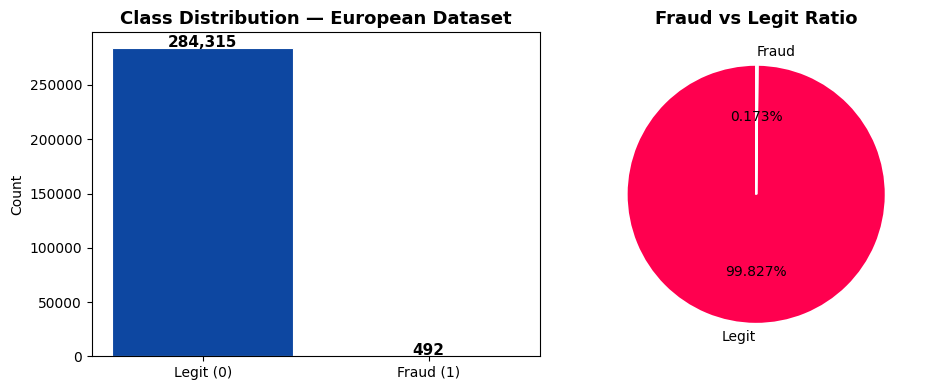


Plot saved: euro_class_distribution.png


In [ ]:
# ── Plot 1: Class Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['Class'].value_counts()
axes[0].bar(['Legit (0)', 'Fraud (1)'], counts.values,
            color=['#0D47A1', '#F44336'], edgecolor='white', linewidth=0.8)
axes[0].set_title('Class Distribution — European Dataset', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=['Legit', 'Fraud'],
            colors=['#ff004f', '#F44336'],
            autopct='%1.3f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Fraud vs Legit Ratio', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: euro_class_distribution.png")

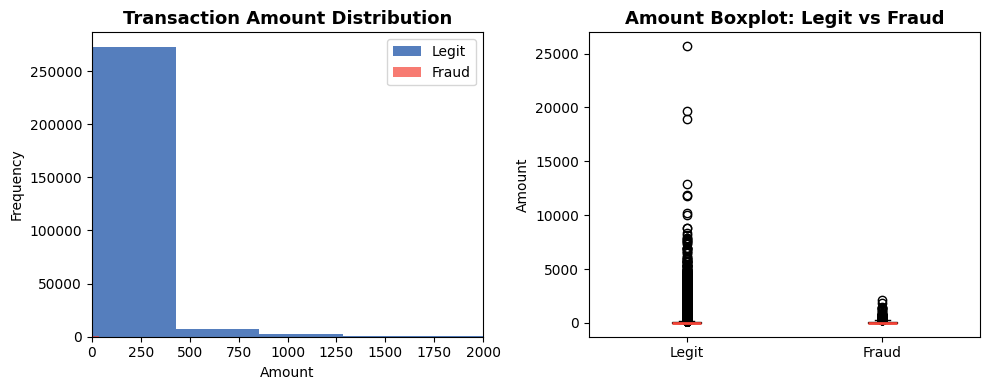


Plot saved: euro_amount_distribution.png


In [ ]:
# ── Plot 2: Amount Distribution by Class ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

fraud_amt   = df[df['Class'] == 1]['Amount']
legit_amt   = df[df['Class'] == 0]['Amount']

axes[0].hist(legit_amt, bins=60, color='#0D47A1', alpha=0.7, label='Legit')
axes[0].hist(fraud_amt, bins=60, color='#F44336', alpha=0.7, label='Fraud')
axes[0].set_title('Transaction Amount Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 2000)

axes[1].boxplot([legit_amt, fraud_amt], labels=['Legit', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Amount Boxplot: Legit vs Fraud', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: euro_amount_distribution.png")

# **PREPROCESSING**

In [ ]:
# Drop Time column if present
if 'Time' in df.columns:
    df = df.drop('Time', axis=1)
    print("  Dropped: Time column")

  Dropped: Time column


In [ ]:
X = df.drop('Class', axis=1)
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [ ]:
y = df['Class']
y.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [ ]:
#numpy
X = df.drop('Class', axis=1).values
y = df['Class'].values

print(f"X shape   : {X.shape}")
print(f"X dtype   : {X.dtype}")
print(f"X[0]      : {X[0]}")
print()
print(f"y shape   : {y.shape}")
print(f"y dtype   : {y.dtype}")
print(f"y unique  : {np.unique(y)}")
print(f"Fraud     : {y.sum()}")
print(f"Legit     : {len(y) - y.sum()}")

X shape   : (284807, 29)
X dtype   : float64
X[0]      : [-1.35980713e+00 -7.27811733e-02  2.53634674e+00  1.37815522e+00
 -3.38320770e-01  4.62387778e-01  2.39598554e-01  9.86979013e-02
  3.63786970e-01  9.07941720e-02 -5.51599533e-01 -6.17800856e-01
 -9.91389847e-01 -3.11169354e-01  1.46817697e+00 -4.70400525e-01
  2.07971242e-01  2.57905802e-02  4.03992960e-01  2.51412098e-01
 -1.83067779e-02  2.77837576e-01 -1.10473910e-01  6.69280749e-02
  1.28539358e-01 -1.89114844e-01  1.33558377e-01 -2.10530535e-02
  1.49620000e+02]

y shape   : (284807,)
y dtype   : int64
y unique  : [0 1]
Fraud     : 492
Legit     : 284315


In [ ]:
# to find the column of amount
amount_col_idx = list(df.drop('Class', axis=1).columns).index('Amount')
print(amount_col_idx)

28


In [ ]:
scaler_euro = StandardScaler()
X[:, amount_col_idx] = scaler_euro.fit_transform(X[:, amount_col_idx].reshape(-1, 1)).ravel()
# Print first 5 rows of scaled data
print("First 5 scaled amounts:")
X[:, amount_col_idx]

First 5 scaled amounts:


array([ 0.24496426, -0.34247454,  1.16068593, ..., -0.0818393 ,
       -0.31324853,  0.51435531])

In [ ]:
print(f"  Features shape : {X.shape}")
print(f"  Target shape   : {y.shape}")

  Features shape : (284807, 29)
  Target shape   : (284807,)


In [ ]:
# Save scaler
with open(SAVE_DIR + 'scaler_euro.pkl', 'wb') as f:pickle.dump({'scaler': scaler_euro, 'amount_idx': amount_col_idx,'feature_names': list(df.drop('Class', axis=1).columns)}, f)
print(" Scaler saved: scaler_euro.pkl")

 Scaler saved: scaler_euro.pkl


In [ ]:
# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(227845, 29)
(56962, 29)


In [ ]:
print(y_train.shape)
print(y_test.shape)

(227845,)
(56962,)


In [ ]:
print(f"  Train fraud count: {y_train.sum()}")
print(f"  Test  fraud count: {y_test.sum()}")

  Train fraud count: 394
  Test  fraud count: 98


In [ ]:
# Compute dynamic alpha for focal loss
n_legit = np.sum(y_train == 0)
n_fraud = np.sum(y_train == 1)
print(f" n_legit      : {n_legit}")
print(f" n_fraud      : {n_fraud}")

 n_legit      : 227451
 n_fraud      : 394


In [ ]:
alpha_fraud = n_legit / (n_fraud + n_legit)
print(f"  Fraud ratio  : {n_fraud / len(y_train) * 100:.4f}%")
print(f"  Alpha (fraud): {alpha_fraud:.4f}")
print(f"  1-Alpha      : {1 - alpha_fraud:.4f}")

  Fraud ratio  : 0.1729%
  Alpha (fraud): 0.9983
  1-Alpha      : 0.0017


In [ ]:
# Reshape for Conv1D → (samples, timesteps, 1)
X_train_3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_3d  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)
print(X_train_3d.shape)
print(X_test_3d.shape)

(227845, 29, 1)
(56962, 29, 1)


# **Focal Loss**

In [ ]:
def focal_loss(alpha=alpha_fraud, gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        bce     = K.binary_crossentropy(y_true, y_pred)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        #fomula for focal loss
        focal   = alpha_t * K.pow(1 - p_t, gamma) * bce
        return K.mean(focal)
    return loss_fn

print(f"  Focal Loss ready")
print(f"  alpha = {alpha_fraud:.4f} (fraud weight = legit proportion)")
print(f"  1-alpha = {1-alpha_fraud:.4f} (legit weight = fraud proportion)")
print(f"  gamma = 2.0 (standard value)")

  Focal Loss ready
  alpha = 0.9983 (fraud weight = legit proportion)
  1-alpha = 0.0017 (legit weight = fraud proportion)
  gamma = 2.0 (standard value)


# **MODEL — CNN + BiLSTM + ATTENTION**

In [ ]:
def build_model(n_features, alpha_val):
    inp = Input(shape=(n_features, 1))

    # ── CNN Block ───────────────────────────────────────────
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inp)
    x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2, padding='same')(x)
    x = Dropout(0.3)(x)

    # ── BiLSTM Block ────────────────────────────────────────
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Bidirectional(LSTM(32, return_sequences=True))(x)

    # ── Attention Block ─────────────────────────────────────
    # Score each timestep
    attn = Dense(1, activation='tanh')(x)
    attn = Flatten()(attn)
    attn = Activation('softmax')(attn)
    attn = Reshape((K.int_shape(x)[1], 1))(attn)
    x    = Multiply()([x, attn])            # weighted features
    x    = GlobalAveragePooling1D()(x)

    # ── Dense Head ──────────────────────────────────────────
    x   = Dense(64, activation='relu')(x)
    x   = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=focal_loss(alpha=alpha_val, gamma=2.0),
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall'),
                 tf.keras.metrics.AUC(name='auc')]
    )
    return model

model_euro = build_model(X_train.shape[1], alpha_fraud)
model_euro.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 29, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 29, 64)    │        256 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 29, 32)    │      6,176 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 15, 32)    │          0 │ conv1d_7[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 15, 32)    │          0 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 15, 128)   │     49,664 │ dropout_6[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 15, 64)    │     41,216 │ bidirectional_6[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 15, 1)     │         65 │ bidirectional_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 15)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 15)        │          0 │ flatten_3[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 15, 1)     │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_3          │ (None, 15, 64)    │          0 │ bidirectional_7[… │
│ (Multiply)          │                   │            │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ multiply_3[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1)         │         65 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 101,602 (396.88 KB)

 Trainable params: 101,602 (396.88 KB)

 Non-trainable params: 0 (0.00 B)

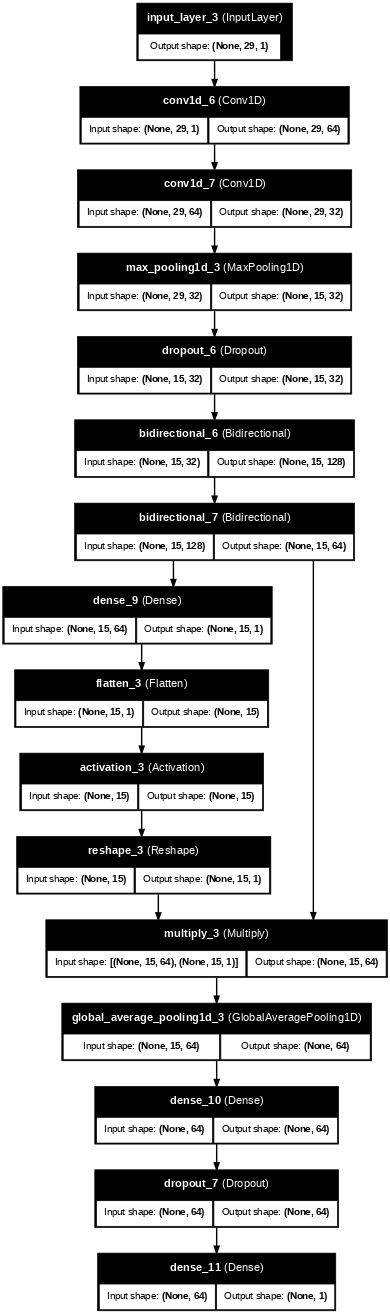


Plot saved: euro_model_architecture.png


In [ ]:
# ── Plot 3: Model Architecture ───────────────────────────────
tf.keras.utils.plot_model(
    model_euro,
    to_file=SAVE_DIR + 'euro_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=50
  )


# Display saved model architecture
display(Image(SAVE_DIR + 'euro_model_architecture.png'))
print("\nPlot saved: euro_model_architecture.png")

# **TRAIN WITH EARLYSTOPPING**

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True, verbose=1),
    ModelCheckpoint(SAVE_DIR + 'best_euro_model.h5',monitor='val_auc', save_best_only=True,mode='max', verbose=0)
]

In [ ]:
#227,845÷64=3,560 full batches + 1 small batch of 5 samples
#Remaining = 227,845 − 227,840 = 5
history = model_euro.fit(
    X_train_3d, y_train,
    validation_data=(X_test_3d, y_test),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
3560/3561 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9750 - auc: 0.8739 - loss: 3.2942e-04 - precision: 0.0549 - recall: 0.7506

3561/3561 ━━━━━━━━━━━━━━━━━━━━ 232s 62ms/step - accuracy: 0.9778 - auc: 0.9252 - loss: 2.6415e-04 - precision: 0.0612 - recall: 0.8249 - val_accuracy: 0.9956 - val_auc: 0.9546 - val_loss: 2.0797e-04 - val_precision: 0.2646 - val_recall: 0.8776
Epoch 2/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9829 - auc: 0.9181 - loss: 2.4623e-04 - precision: 0.0834 - recall: 0.8308

3561/3561 ━━━━━━━━━━━━━━━━━━━━ 195s 55ms/step - accuracy: 0.9846 - auc: 0.9381 - loss: 2.2707e-04 - precision: 0.0883 - recall: 0.8477 - val_accuracy: 0.9934 - val_auc: 0.9553 - val_loss: 1.8793e-04 - val_precision: 0.1920 - val_recall: 0.8776
Epoch 3/50
3560/3561 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9801 - auc: 0.9416 - loss: 2.3453e-04 - precision: 0.0751 - recall: 0.8437

3561/3561 ━━━━━━━━━━━━━━━━━━━━ 199s 56ms/step - accuracy: 0.9849 - auc: 0.9525 - loss: 2.0722e-04 - precision: 0.0907 - recall: 0.8579 - val_accuracy: 0.9974 - val_auc: 0.9631 - val_loss: 1.8809e-04 - val_precision: 0.3884 - val_recall: 0.8878
Epoch 4/50
3560/3561 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9850 - auc: 0.9622 - loss: 1.7588e-04 - precision: 0.0991 - recall: 0.8826

3561/3561 ━━━━━━━━━━━━━━━━━━━━ 214s 60ms/step - accuracy: 0.9839 - auc: 0.9594 - loss: 1.9767e-04 - precision: 0.0866 - recall: 0.8680 - val_accuracy: 0.9877 - val_auc: 0.9723 - val_loss: 1.5904e-04 - val_precision: 0.1121 - val_recall: 0.8878
Epoch 5/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 253s 57ms/step - accuracy: 0.9846 - auc: 0.9604 - loss: 1.8968e-04 - precision: 0.0902 - recall: 0.8680 - val_accuracy: 0.9928 - val_auc: 0.9652 - val_loss: 1.7375e-04 - val_precision: 0.1790 - val_recall: 0.8878
Epoch 6/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 207s 58ms/step - accuracy: 0.9893 - auc: 0.9657 - loss: 1.8410e-04 - precision: 0.1240 - recall: 0.8553 - val_accuracy: 0.9694 - val_auc: 0.9692 - val_loss: 1.8798e-04 - val_precision: 0.0489 - val_recall: 0.9082
Epoch 7/50
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 256s 56ms/step - accuracy: 0.9831 - auc: 0.9707 - loss: 1.7594e-04 - precision: 0.0830 - recall: 0.8731 - val_accuracy: 0.9887 - val_auc: 0.9653 - val_loss: 1.7081e-04 - val_precision: 0.1222 - val_recall

In [ ]:
model_euro.save(SAVE_DIR + 'euro_model.h5')
print("Model saved: euro_model.h5")

euro_final = {
    'train_loss':     history.history['loss'][-1],
    'val_loss':       history.history['val_loss'][-1],
    'train_accuracy': history.history['accuracy'][-1],
    'val_accuracy':   history.history['val_accuracy'][-1],
    'train_recall':   history.history['recall'][-1],
    'val_recall':     history.history['val_recall'][-1],
    'train_auc':      history.history['auc'][-1],
    'val_auc':        history.history['val_auc'][-1],
    'epochs_run':     len(history.history['loss'])
}
with open(SAVE_DIR + 'euro_metrics.pkl', 'wb') as f:pickle.dump(euro_final, f)
print(f"\nEuro metrics saved ")
print(f"  Val Accuracy : {euro_final['val_accuracy']:.4f}")
print(f"  Val Loss     : {euro_final['val_loss']:.4f}")
print(f"  Val AUC      : {euro_final['val_auc']:.4f}")
print(f"\nEpochs ran   : {euro_final['epochs_run']} / 50")

Model saved: euro_model.h5

Euro metrics saved 
  Val Accuracy : 0.9872
  Val Loss     : 0.0002
  Val AUC      : 0.9710

Epochs ran   : 9 / 50


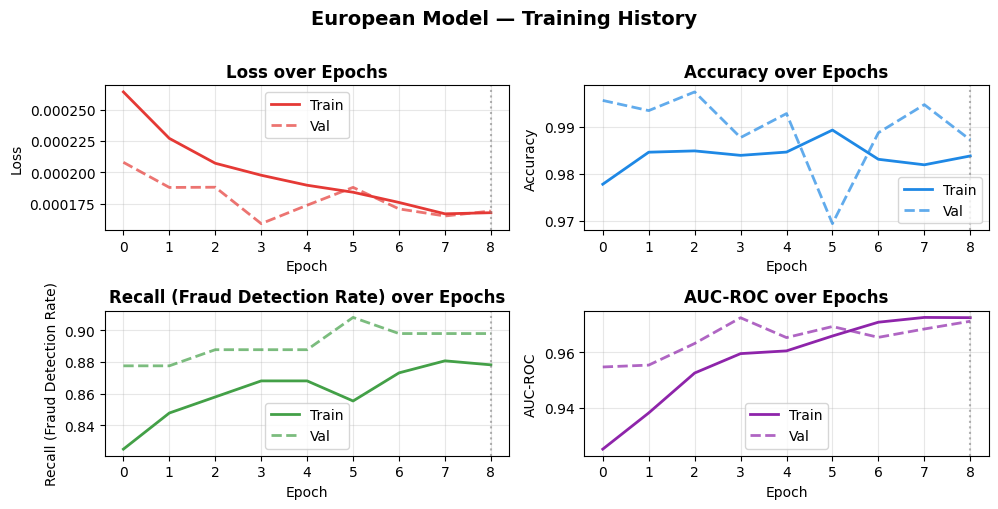


Plot saved: euro_training_history.png


In [ ]:
# ── Plot 4: Training History ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 5))

metrics = [('loss', 'val_loss', 'Loss', '#E53935'),
           ('accuracy', 'val_accuracy', 'Accuracy', '#1E88E5'),
           ('recall', 'val_recall', 'Recall (Fraud Detection Rate)', '#43A047'),
           ('auc', 'val_auc', 'AUC-ROC', '#8E24AA')]

for ax, (tr_key, val_key, title, color) in zip(axes.flatten(), metrics):
    if tr_key in history.history:
        ax.plot(history.history[tr_key],  label='Train', color=color, linewidth=2)
        ax.plot(history.history[val_key], label='Val',   color=color,
                linewidth=2, linestyle='--', alpha=0.7)
        ax.set_title(f'{title} over Epochs', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(alpha=0.3)
        stopped = len(history.history[tr_key])
        ax.axvline(x=stopped - 1, color='gray', linestyle=':', alpha=0.6,
                   label=f'Stopped @ {stopped}')

plt.suptitle('European Model — Training History', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: euro_training_history.png")


# **EVALUATION**

In [ ]:
y_prob = model_euro.predict(X_test_3d).ravel()
y_pred = (y_prob > 0.5).astype(int)
y_pred.shape

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step


(56962,)

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99     56864
       Fraud       0.11      0.89      0.20        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962


ROC-AUC: 0.9722


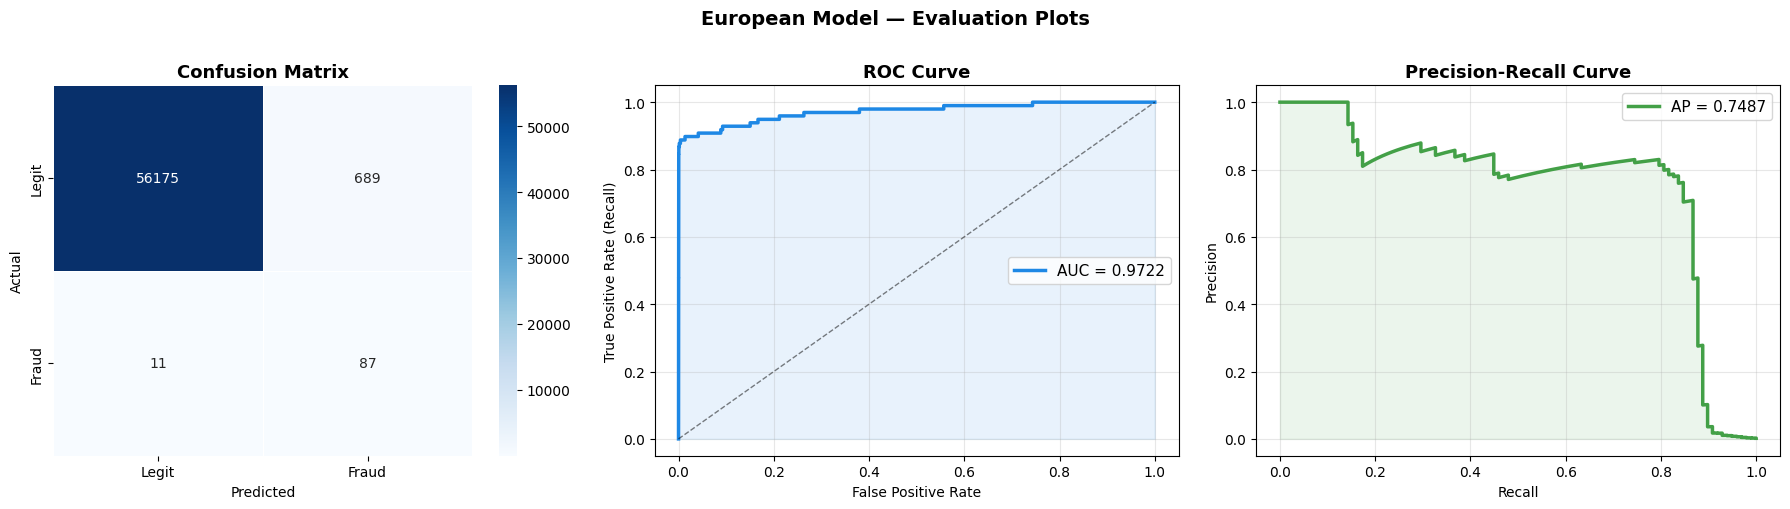


Plot saved: euro_evaluation.png


In [ ]:
# ── Plot 5: Confusion Matrix ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ── ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#1E88E5', linewidth=2.5, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#1E88E5')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

# ── Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[2].plot(rec, prec, color='#43A047', linewidth=2.5, label=f'AP = {ap:.4f}')
axes[2].fill_between(rec, prec, alpha=0.1, color='#43A047')
axes[2].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(fontsize=11)
axes[2].grid(alpha=0.3)

plt.suptitle('European Model — Evaluation Plots', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: euro_evaluation.png")

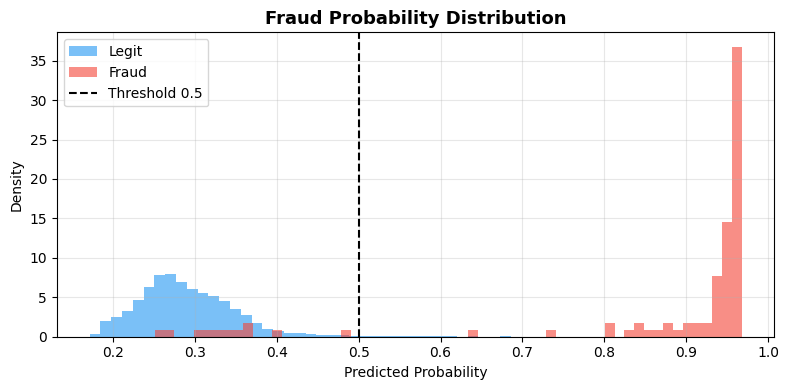


Plot saved: euro_prob_distribution.png


In [ ]:
# ── Plot 6: Probability Distribution ────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_prob[y_test == 0], bins=60, color='#2196F3', alpha=0.6,
        label='Legit', density=True)
ax.hist(y_prob[y_test == 1], bins=60, color='#F44336', alpha=0.6,
        label='Fraud', density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.5')
ax.set_title('Fraud Probability Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_prob_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: euro_prob_distribution.png")

# **SHAP EXPLAINABILITY**

In [ ]:
feature_names = list(df.drop('Class', axis=1).columns)

# Use a small background sample for speed
background   = X_train_3d[:100]
explain_data = X_test_3d[:50]

print(f"  Background shape : {background.shape}")
print(f"  Explain shape    : {explain_data.shape}")
print("   Computing SHAP values...")

explainer_euro   = shap.GradientExplainer(model_euro, background)
shap_values_euro = explainer_euro.shap_values(explain_data)

# shap_values shape: (samples, timesteps, 1) — collapse to 2D
sv_2d = np.array(shap_values_euro).squeeze()
if sv_2d.ndim == 3:
    sv_2d = sv_2d.mean(axis=1)  # average over timesteps

X_sample_2d = explain_data.squeeze()  # (50, n_features)

# GradientExplainer has no expected_value — use mean prediction as base_val
base_val = float(model_euro.predict(background).mean())

print(f"\n  SHAP values shape : {sv_2d.shape}")
print(f"  Base value        : {base_val:.4f}")

  Background shape : (100, 29, 1)
  Explain shape    : (50, 29, 1)
   Computing SHAP values...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

  SHAP values shape : (50, 29)
  Base value        : 0.2880


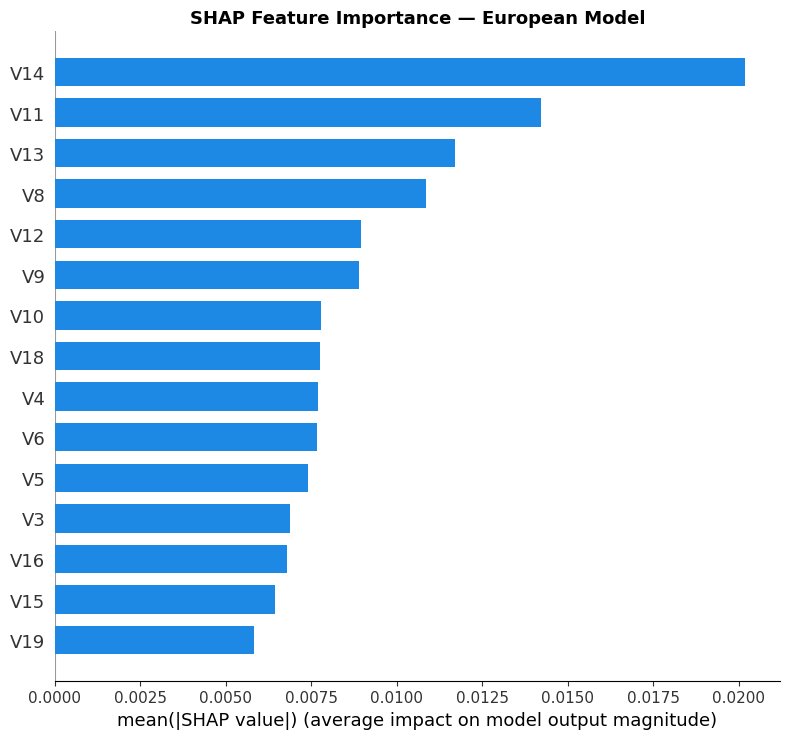


Plot saved: euro_shap_bar.png


In [ ]:
# ── Plot 7: SHAP Summary Bar ─────────────────────────────────
plt.figure(figsize=(8, 5))
shap.summary_plot(sv_2d, explain_data.squeeze(),
                  feature_names=feature_names,
                  plot_type='bar', show=False,
                  max_display=15, color='#1E88E5')
plt.title('SHAP Feature Importance — European Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: euro_shap_bar.png")

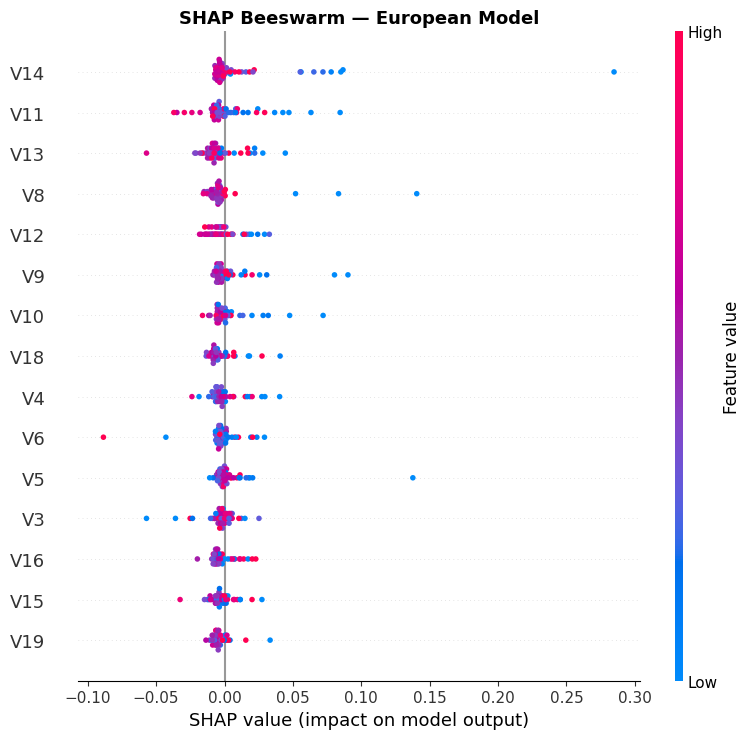


Plot saved: euro_shap_beeswarm.png


In [ ]:
# ── Plot 8: SHAP Beeswarm ────────────────────────────────────
plt.figure(figsize=(10, 5))
shap.summary_plot(sv_2d, explain_data.squeeze(),
                  feature_names=feature_names,
                  show=False, max_display=15)
plt.title('SHAP Beeswarm — European Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: euro_shap_beeswarm.png")

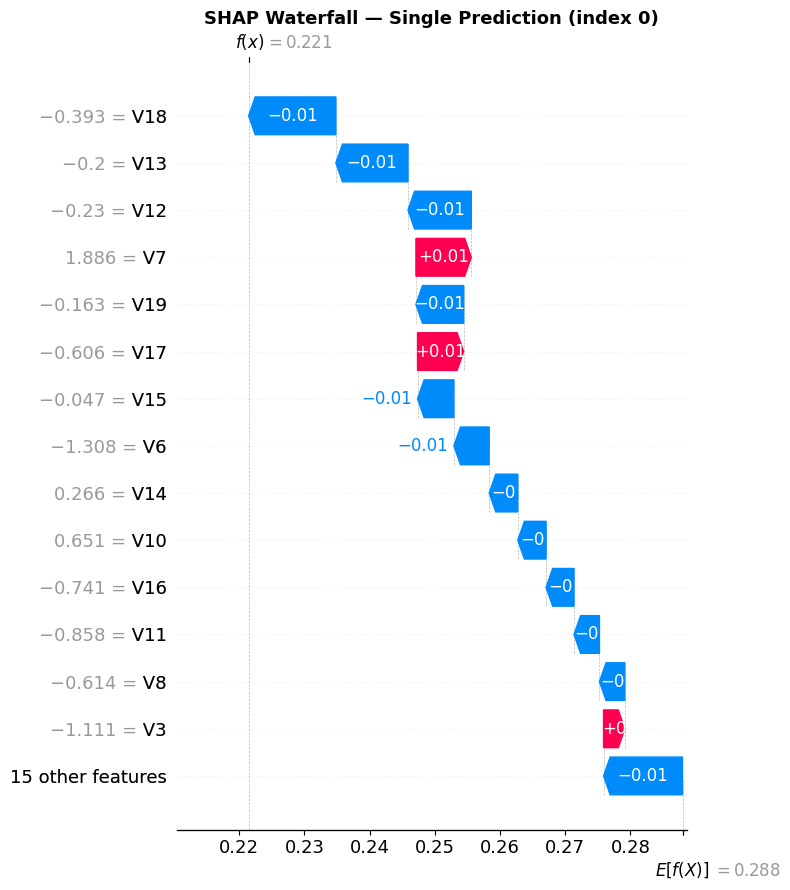


Plot saved: euro_shap_waterfall.png


In [ ]:
# ── Plot 9: SHAP Waterfall Plot (Single Prediction) ──────────
# Explains one prediction step-by-step from base value to final output
shap_exp = shap.Explanation(
    values       = sv_2d[0],
    base_values  = base_val,
    data         = X_sample_2d[0],
    feature_names= feature_names
)
plt.figure(figsize=(12, 7))
shap.plots.waterfall(shap_exp, max_display=15, show=False)
plt.title('SHAP Waterfall — Single Prediction (index 0)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: euro_shap_waterfall.png")

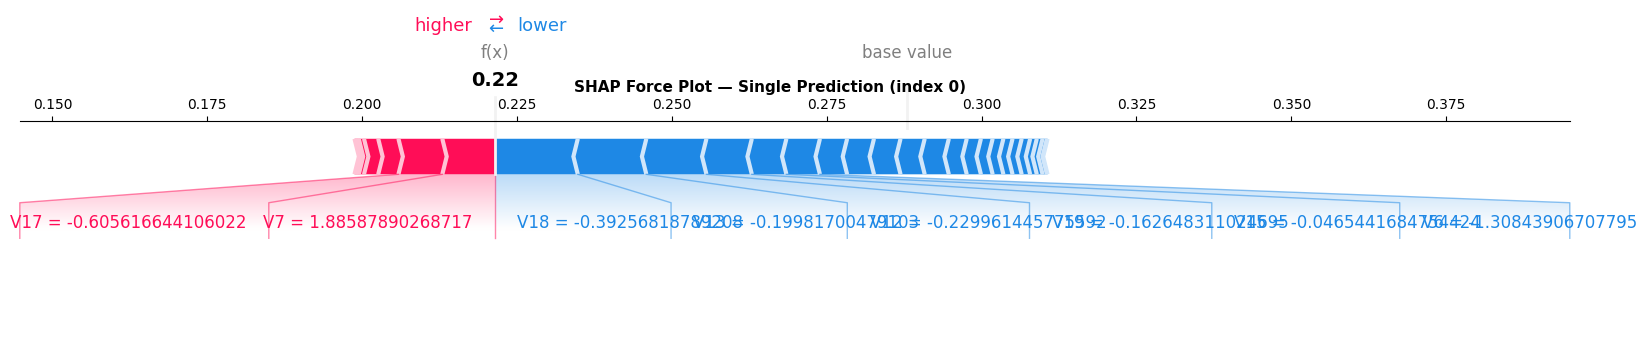


 Plot saved: euro_shap_force.png


In [ ]:
# ── Plot 10: SHAP Force Plot (Single Prediction) ─────────────
# Interactive-style force plot saved as PNG via matplotlib

shap.force_plot(
    base_val,
    sv_2d[0],
    X_sample_2d[0],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
# force_plot internally creates its own figure — use gcf() to access it
plt.gcf().suptitle('SHAP Force Plot — Single Prediction (index 0)',fontsize=11, fontweight='bold', y=1.02)

plt.savefig(SAVE_DIR + 'euro_shap_force.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Plot saved: euro_shap_force.png")

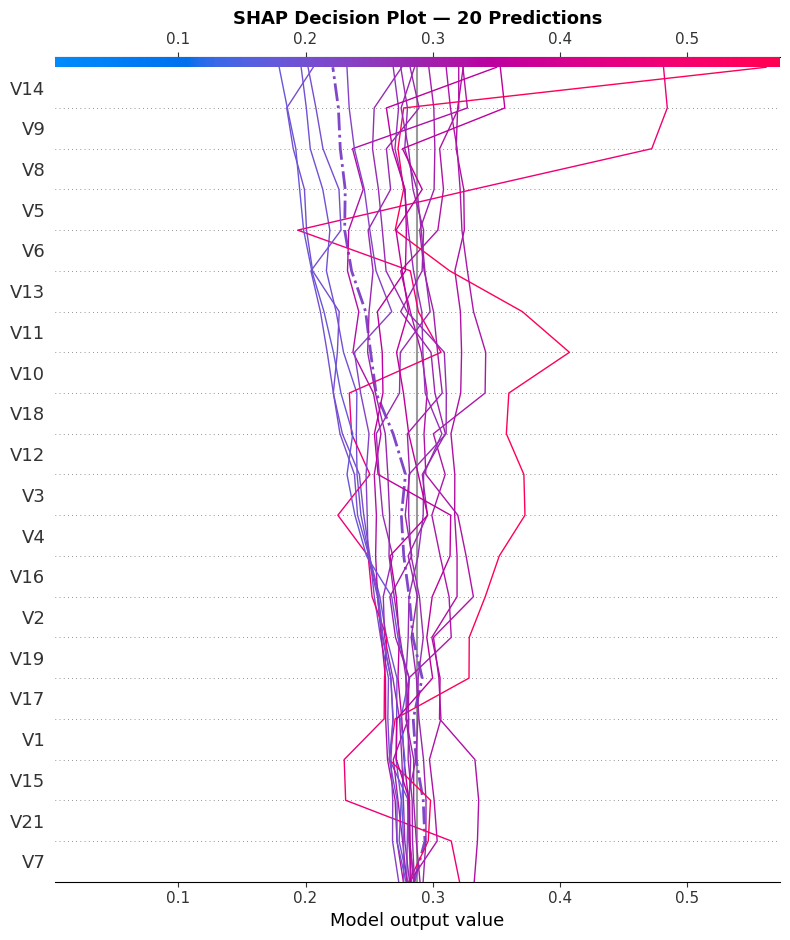


 Plot saved: euro_shap_decision.png


In [ ]:
# ── Plot 11: SHAP Decision Plot (Multiple Predictions) ───────
# Shows the path from base value to final prediction for multiple samples
plt.figure(figsize=(10, 5))
shap.decision_plot(
    base_val,
    sv_2d[:20],           # first 20 samples
    X_sample_2d[:20],
    feature_names=feature_names,
    show=False,
    highlight=0           # highlight first sample
)
plt.title('SHAP Decision Plot — 20 Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_shap_decision.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Plot saved: euro_shap_decision.png")

<Figure size 900x600 with 0 Axes>

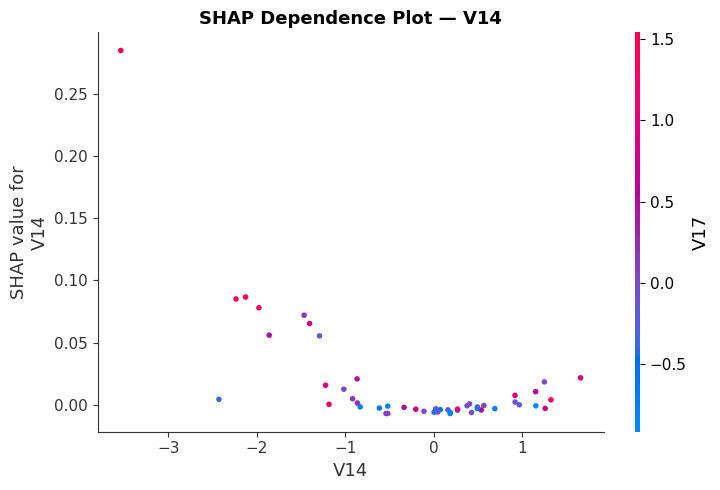


 Plot saved: euro_shap_dependence.png  (feature: V14)


In [ ]:
# ── Plot 12: SHAP Dependence Plot (Top Feature) ──────────────
# Scatter: top feature SHAP value vs feature value, colored by interaction feature
top_feature_idx = np.argmax(np.abs(sv_2d).mean(axis=0))
top_feature_name = feature_names[top_feature_idx]

plt.figure(figsize=(9, 6))
shap.dependence_plot(
    top_feature_idx,
    sv_2d,
    X_sample_2d,
    feature_names=feature_names,
    show=False
)
plt.title(f'SHAP Dependence Plot — {top_feature_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n Plot saved: euro_shap_dependence.png  (feature: {top_feature_name})")

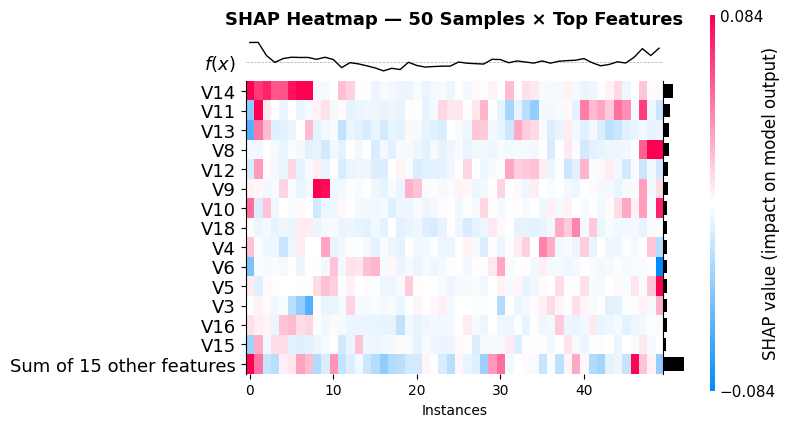


 Plot saved: euro_shap_heatmap.png


In [ ]:
# ── Plot 13: SHAP Heatmap ─────────────────────────────────────
# Matrix of SHAP values across observations — spot patterns easily
shap_exp_all = shap.Explanation(
    values       = sv_2d,
    base_values  = np.full(sv_2d.shape[0], base_val),
    data         = X_sample_2d,
    feature_names= feature_names
)
plt.figure(figsize=(14, 8))
shap.plots.heatmap(shap_exp_all, max_display=15, show=False)
plt.title('SHAP Heatmap — 50 Samples × Top Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_shap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Plot saved: euro_shap_heatmap.png")

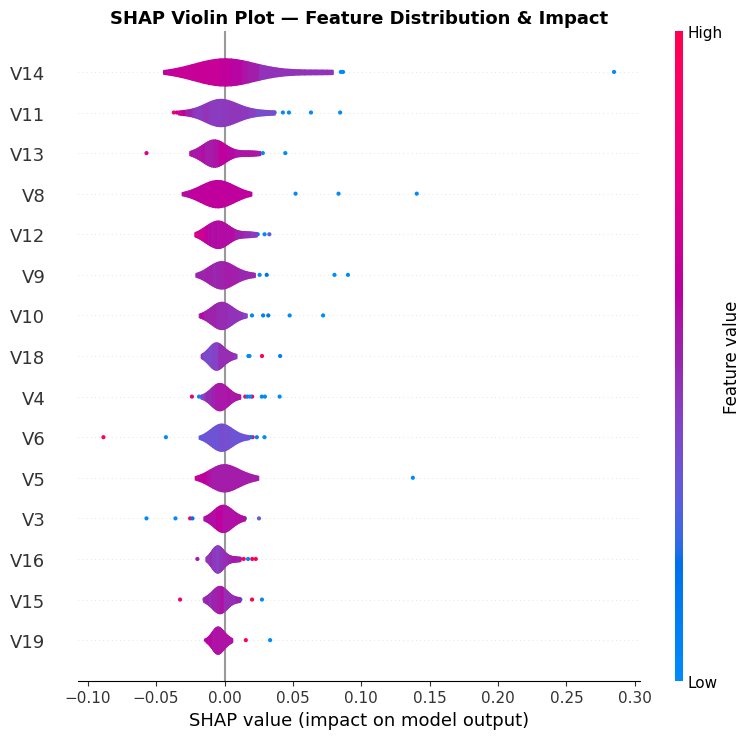


 Plot saved: euro_shap_violin.png


In [ ]:
# ── Plot 14: SHAP Violin Plot ─────────────────────────────────
# Feature distribution + SHAP values — density & spread together
plt.figure(figsize=(10, 7))
shap.summary_plot(sv_2d, X_sample_2d,
                  feature_names=feature_names,
                  plot_type='violin',
                  show=False,
                  max_display=15)
plt.title('SHAP Violin Plot — Feature Distribution & Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'euro_shap_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Plot saved: euro_shap_violin.png")

In [ ]:
# Save explainer
with open(SAVE_DIR + 'shap_explainer_euro.pkl', 'wb') as f:
    pickle.dump({'shap_values': sv_2d,
                 'feature_names': feature_names,
                 'X_sample': explain_data.squeeze(),
                 'base_value': base_val
                 }, f)
print("SHAP data saved: shap_explainer_euro.pkl")

SHAP data saved: shap_explainer_euro.pkl


In [ ]:
# ── Save test data for Streamlit demo ────────────────────────
np.save(SAVE_DIR + 'euro_X_test.npy', X_test)
np.save(SAVE_DIR + 'euro_y_test.npy', y_test)
print("Test data saved for demo")

Test data saved for demo


# **EUROPEAN TRAINING COMPLETE**

# **INDIAN DATASET TRAINING**

# **LOAD & EXPLORE**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/fraud_project/indian.csv")
df.head()

,transaction_id,customer_id,merchant_id,amount,transaction_time,is_fraudulent,card_type,location,purchase_category,customer_age,fraud_type
0,1.0,684415.0,2028.0,1262.770,11/24/2023 22:39,0.0,Rupay,Bangalore,NaN,28.0,Identity theft
1,2.0,447448.0,2046.0,2222.928,03/30/2024 16:18,0.0,MasterCard,Surat,POS,62.0,Malware
2,3.0,975001.0,2067.0,7509.832,03/07/2024 18:27,0.0,MasterCard,Hyderabad,POS,24.0,Malware
3,4.0,976547.0,NaN,2782.965,02/01/2024 00:58,0.0,Rupay,Hyderabad,Digital,62.0,Payment card fraud
4,5.0,935741.0,2044.0,NaN,12/22/2023 18:42,0.0,NaN,Bangalore,Digital,19.0,scam


In [ ]:
print(f"Shape         : {df.shape}")
print(f"Columns       : {list(df.columns)}")

Shape         : (7953, 11)
Columns       : ['transaction_id', 'customer_id', 'merchant_id', 'amount', 'transaction_time', 'is_fraudulent', 'card_type', 'location', 'purchase_category', 'customer_age', 'fraud_type']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7953 entries, 0 to 7952
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     7478 non-null   float64
 1   customer_id        7532 non-null   float64
 2   merchant_id        7481 non-null   float64
 3   amount             7261 non-null   float64
 4   transaction_time   7385 non-null   object 
 5   is_fraudulent      7228 non-null   float64
 6   card_type          7386 non-null   object 
 7   location           7430 non-null   object 
 8   purchase_category  7421 non-null   object 
 9   customer_age       7285 non-null   float64
 10  fraud_type         7455 non-null   object 
dtypes: float64(6), object(5)
memory usage: 683.6+ KB


In [ ]:
print(f"\nMissing values:")
print(df.isnull().sum())


Missing values:
transaction_id       475
customer_id          421
merchant_id          472
amount               692
transaction_time     568
is_fraudulent        725
card_type            567
location             523
purchase_category    532
customer_age         668
fraud_type           498
dtype: int64


In [ ]:
print(f"\nTarget distribution:\n")
print(df['is_fraudulent'].value_counts())
print(f"Fraud % : {df['is_fraudulent'].dropna().mean() * 100:.2f}%")


Target distribution:

is_fraudulent
0.0    4963
1.0    2265
Name: count, dtype: int64
Fraud % : 31.34%


# **EXPLORE PLOTS**

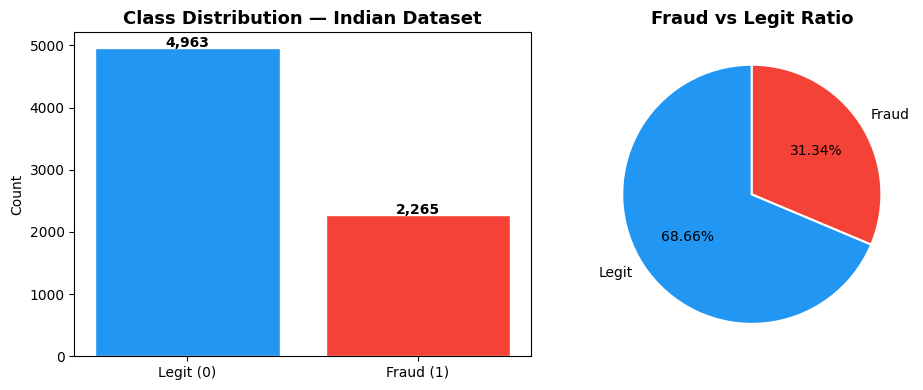


Plot saved: indian_class_distribution.png


In [ ]:
# ── Plot 1: Class Distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['is_fraudulent'].dropna().value_counts()
axes[0].bar(['Legit (0)', 'Fraud (1)'], counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Class Distribution — Indian Dataset',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Legit', 'Fraud'],
            colors=['#2196F3', '#F44336'],
            autopct='%1.2f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Fraud vs Legit Ratio', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_class_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: indian_class_distribution.png")

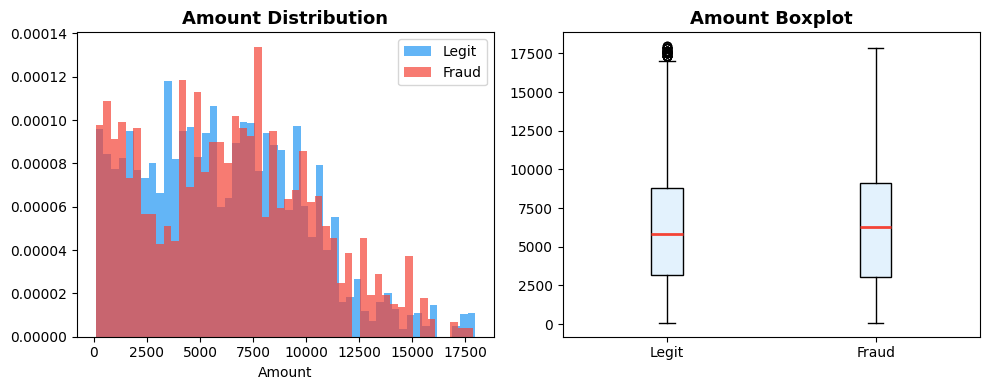


Plot saved: indian_amount_distribution.png


In [ ]:
# ── Plot 2: Amount distribution ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_temp = df.dropna(subset=['amount', 'is_fraudulent'])
fraud_amt = df_temp[df_temp['is_fraudulent'] == 1]['amount']
legit_amt = df_temp[df_temp['is_fraudulent'] == 0]['amount']

axes[0].hist(legit_amt, bins=50, color='#2196F3',
             alpha=0.7, label='Legit', density=True)
axes[0].hist(fraud_amt, bins=50, color='#F44336',
             alpha=0.7, label='Fraud', density=True)
axes[0].set_title('Amount Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount'); axes[0].legend()

axes[1].boxplot([legit_amt, fraud_amt], labels=['Legit', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#E3F2FD'),
                medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Amount Boxplot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_amount_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: indian_amount_distribution.png")

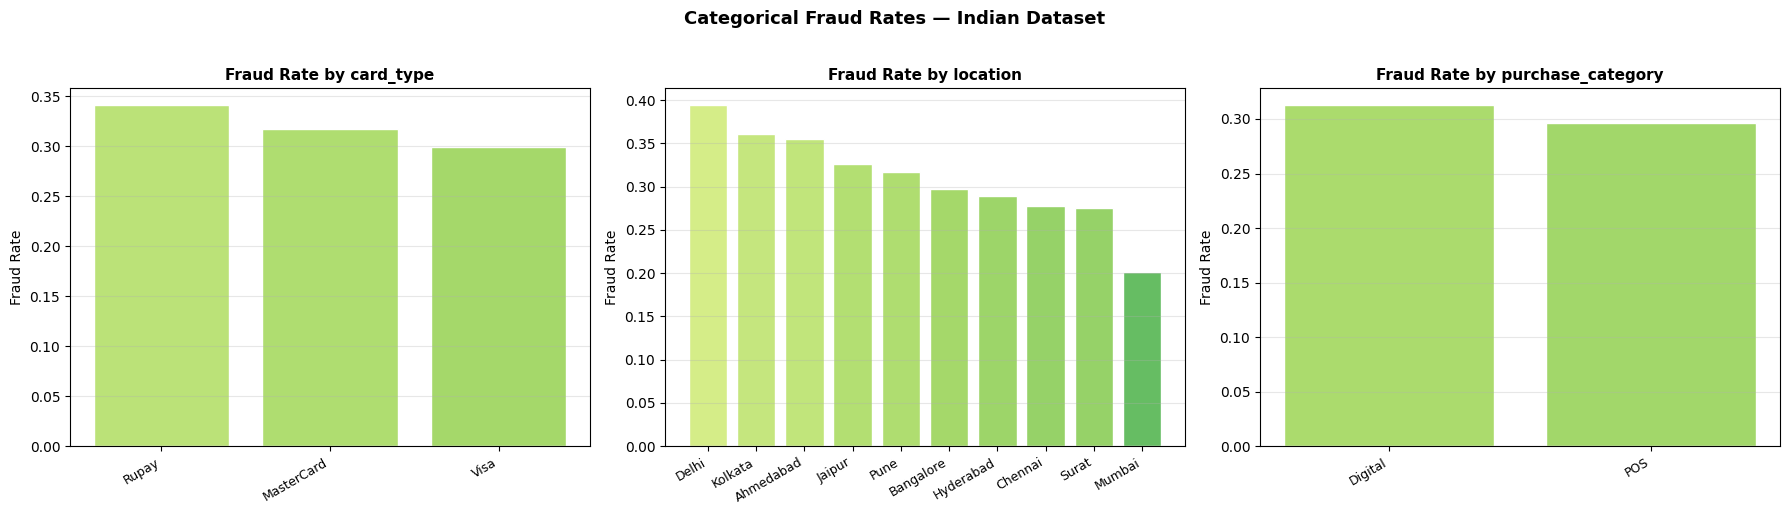


Plot saved: indian_fraud_rates_categorical.png


In [ ]:
# ── Plot 3: Categorical fraud rates ──────────────────────────
cat_plot_cols = ['card_type', 'location', 'purchase_category']
cat_plot_cols = [c for c in cat_plot_cols if c in df.columns]

fig, axes = plt.subplots(1, len(cat_plot_cols),
                          figsize=(6 * len(cat_plot_cols), 5))
if len(cat_plot_cols) == 1:
    axes = [axes]

df_temp2 = df.dropna(subset=['is_fraudulent'])
for ax, col in zip(axes, cat_plot_cols):
    temp = df_temp2.dropna(subset=[col])
    fraud_rate = temp.groupby(col)['is_fraudulent'].mean() \
                     .sort_values(ascending=False)
    ax.bar(range(len(fraud_rate)), fraud_rate.values,
           color=plt.cm.RdYlGn_r(fraud_rate.values),
           edgecolor='white')
    ax.set_xticks(range(len(fraud_rate)))
    ax.set_xticklabels(fraud_rate.index, rotation=30,
                       ha='right', fontsize=9)
    ax.set_title(f'Fraud Rate by {col}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Fraud Rate')
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Categorical Fraud Rates — Indian Dataset',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_fraud_rates_categorical.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: indian_fraud_rates_categorical.png")

# **PREPROCESSING**

In [ ]:
df_proc = df.copy()
df_proc.head()

,transaction_id,customer_id,merchant_id,amount,transaction_time,is_fraudulent,card_type,location,purchase_category,customer_age,fraud_type
0,1.0,684415.0,2028.0,1262.770,11/24/2023 22:39,0.0,Rupay,Bangalore,NaN,28.0,Identity theft
1,2.0,447448.0,2046.0,2222.928,03/30/2024 16:18,0.0,MasterCard,Surat,POS,62.0,Malware
2,3.0,975001.0,2067.0,7509.832,03/07/2024 18:27,0.0,MasterCard,Hyderabad,POS,24.0,Malware
3,4.0,976547.0,NaN,2782.965,02/01/2024 00:58,0.0,Rupay,Hyderabad,Digital,62.0,Payment card fraud
4,5.0,935741.0,2044.0,NaN,12/22/2023 18:42,0.0,NaN,Bangalore,Digital,19.0,scam


In [ ]:
# ── Step 1: Drop rows where TARGET is missing ────────────────
# Never fill target column
before = len(df_proc)
df_proc = df_proc.dropna(subset=['is_fraudulent'])
print(f"  Dropped {before - len(df_proc)} rows with missing is_fraudulent")
print(f"  Remaining: {len(df_proc)} rows")

  Dropped 725 rows with missing is_fraudulent
  Remaining: 7228 rows


In [ ]:
print(f"\nMissing values:")
print(df_proc.isnull().sum())


Missing values:
transaction_id       426
customer_id          378
merchant_id          447
amount               640
transaction_time     508
is_fraudulent          0
card_type            527
location             486
purchase_category    464
customer_age         563
fraud_type           445
dtype: int64


In [ ]:
# ── Step 2: Drop ID + Time columns ───────────────────────────
drop_cols = ['transaction_id', 'customer_id', 'merchant_id','transaction_time']
drop_cols = [c for c in drop_cols if c in df_proc.columns]
df_proc   = df_proc.drop(columns=drop_cols)
print(f"  Dropped columns: {drop_cols}")

  Dropped columns: ['transaction_id', 'customer_id', 'merchant_id', 'transaction_time']


In [ ]:
df_proc.head()

,amount,is_fraudulent,card_type,location,purchase_category,customer_age,fraud_type
0,1262.770,0.0,Rupay,Bangalore,NaN,28.0,Identity theft
1,2222.928,0.0,MasterCard,Surat,POS,62.0,Malware
2,7509.832,0.0,MasterCard,Hyderabad,POS,24.0,Malware
3,2782.965,0.0,Rupay,Hyderabad,Digital,62.0,Payment card fraud
4,NaN,0.0,NaN,Bangalore,Digital,19.0,scam


In [ ]:
# ── Step 3: Handle missing in CATEGORICAL columns ────────────
# fraud_type: meaningful only for fraud rows
if 'fraud_type' in df_proc.columns:
    # Fraud rows → fill with mode
    fraud_mode = df_proc[df_proc['is_fraudulent'] == 1]['fraud_type'] \
                     .mode()
    fraud_mode = fraud_mode[0] if len(fraud_mode) > 0 else 'Unknown'

    # Legit rows → fill with 'No_Fraud'
    df_proc.loc[df_proc['is_fraudulent'] == 1, 'fraud_type'] = \
        df_proc.loc[df_proc['is_fraudulent'] == 1, 'fraud_type'] \
               .fillna(fraud_mode)
    df_proc.loc[df_proc['is_fraudulent'] == 0, 'fraud_type'] = \
        df_proc.loc[df_proc['is_fraudulent'] == 0, 'fraud_type'] \
               .fillna('No_Fraud')
    print(f"  fraud_type: smart filled ")

  fraud_type: smart filled 


In [ ]:
# Other categorical → Mode fill
other_cat = ['card_type', 'location', 'purchase_category']
for col in other_cat:
    if col in df_proc.columns and df_proc[col].isnull().sum() > 0:
        mode_val = df_proc[col].mode()[0]
        df_proc[col] = df_proc[col].fillna(mode_val)
        print(f"  {col}: filled with mode '{mode_val}'")

  card_type: filled with mode 'Visa'
  location: filled with mode 'Hyderabad'
  purchase_category: filled with mode 'Digital'


In [ ]:
df_proc.head()

,amount,is_fraudulent,card_type,location,purchase_category,customer_age,fraud_type
0,1262.770,0.0,Rupay,Bangalore,Digital,28.0,Identity theft
1,2222.928,0.0,MasterCard,Surat,POS,62.0,Malware
2,7509.832,0.0,MasterCard,Hyderabad,POS,24.0,Malware
3,2782.965,0.0,Rupay,Hyderabad,Digital,62.0,Payment card fraud
4,NaN,0.0,Visa,Bangalore,Digital,19.0,scam


In [ ]:
# ── Step 4: Handle missing in NUMERICAL columns ──────────────
# Median (robust for skewed fraud data)
num_cols_fill = ['amount', 'customer_age']
for col in num_cols_fill:
    if col in df_proc.columns and df_proc[col].isnull().sum() > 0:
        median_val = df_proc[col].median()
        df_proc[col] = df_proc[col].fillna(median_val)
        print(f"  {col}: filled with median {median_val:.2f}")

  amount: filled with median 5993.63
  customer_age: filled with median 44.00


In [ ]:
df_proc.head()

,amount,is_fraudulent,card_type,location,purchase_category,customer_age,fraud_type
0,1262.770,0.0,Rupay,Bangalore,Digital,28.0,Identity theft
1,2222.928,0.0,MasterCard,Surat,POS,62.0,Malware
2,7509.832,0.0,MasterCard,Hyderabad,POS,24.0,Malware
3,2782.965,0.0,Rupay,Hyderabad,Digital,62.0,Payment card fraud
4,5993.625,0.0,Visa,Bangalore,Digital,19.0,scam


In [ ]:
# ── Step 5: Verify no missing ────────────────────────────────
print(f"\n  Missing after fill: {df_proc.isnull().sum().sum()}")


  Missing after fill: 0


In [ ]:
# ── Step 6: Encode categorical columns ──────────────────────
encoders = {}
cat_encode_cols = [c for c in ['card_type', 'location','purchase_category', 'fraud_type']
                   if c in df_proc.columns]

for col in cat_encode_cols:
    le = LabelEncoder()
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))
    encoders[col] = le
    print(f"  Encoded {col}: {list(le.classes_)}")

  Encoded card_type: ['MasterCard', 'Rupay', 'Visa']
  Encoded location: ['Ahmedabad', 'Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai', 'Pune', 'Surat']
  Encoded purchase_category: ['Digital', 'POS']
  Encoded fraud_type: ['Identity theft', 'Malware', 'No_Fraud', 'Payment card fraud', 'phishing', 'scam']


In [ ]:
# After encoding
df_proc.head()

,amount,is_fraudulent,card_type,location,purchase_category,customer_age,fraud_type
0,1262.770,0.0,1,1,0,28.0,0
1,2222.928,0.0,0,9,1,62.0,1
2,7509.832,0.0,0,4,1,24.0,1
3,2782.965,0.0,1,4,0,62.0,3
4,5993.625,0.0,2,1,0,19.0,5


In [ ]:
# ── Step 7: Prepare X, y ────────────────────────────────────
X = df_proc.drop('is_fraudulent', axis=1)
X.head()

,amount,card_type,location,purchase_category,customer_age,fraud_type
0,1262.770,1,1,0,28.0,0
1,2222.928,0,9,1,62.0,1
2,7509.832,0,4,1,24.0,1
3,2782.965,1,4,0,62.0,3
4,5993.625,2,1,0,19.0,5


In [ ]:
y = df_proc['is_fraudulent']
y.head()

,is_fraudulent
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


In [ ]:
# ── Step 7 Final: Clean + Convert ────────────────────────────

# Drop object cols — DataFrame
obj_cols = X.select_dtypes(include='object').columns.tolist()
if obj_cols:
    X = X.drop(columns=obj_cols)
    print(f"  Dropped remaining object cols: {obj_cols}")

# numpy convert
X = X.values.astype(float)
y = df_proc['is_fraudulent'].values.astype(int)
feature_names = list(df_proc.drop('is_fraudulent', axis=1)
                     .select_dtypes(exclude='object').columns)

print(f"X shape        : {X.shape}")
print(f"X dtype        : {X.dtype}")
print(f"X first row    : {X[0]}")
print()
print(f"y shape        : {y.shape}")
print(f"y dtype        : {y.dtype}")
print(f"y unique vals  : {np.unique(y)}")
print(f"Fraud count    : {y.sum()}")
print(f"Legit count    : {len(y) - y.sum()}")
print(f"Feature names  : {feature_names}")

X shape        : (7228, 6)
X dtype        : float64
X first row    : [1.26277e+03 1.00000e+00 1.00000e+00 0.00000e+00 2.80000e+01 0.00000e+00]

y shape        : (7228,)
y dtype        : int64
y unique vals  : [0 1]
Fraud count    : 2265
Legit count    : 4963
Feature names  : ['amount', 'card_type', 'location', 'purchase_category', 'customer_age', 'fraud_type']


In [ ]:
# ── Step 8: Scale ────────────────────────────────────────────
scaler_indian = StandardScaler()
X_scaled      = scaler_indian.fit_transform(X)
# Print first 5 rows of scaled data
print("First 5 scaled amounts:",X_scaled[:5])

First 5 scaled amounts: [[-1.34540218 -0.09913294 -1.26486696 -0.62578407 -1.08846557 -1.46543854]
 [-1.08297427 -1.30338991  1.62157951  1.5979953   1.29924289 -0.9086289 ]
 [ 0.36202868 -1.30338991 -0.18244953  1.5979953  -1.36937245 -0.9086289 ]
 [-0.9299064  -0.09913294 -0.18244953 -0.62578407  1.29924289  0.20499038]
 [-0.0523771   1.10512403 -1.26486696 -0.62578407 -1.72050605  1.31860965]]


In [ ]:
# ── Step 9: Save preprocessing objects ──────────────────────
with open(SAVE_DIR + 'scaler_indian.pkl', 'wb') as f:
    pickle.dump({
        'scaler':       scaler_indian,
        'encoders':     encoders,
        'feature_names': feature_names,
        'cat_cols':     cat_encode_cols
    }, f)
print("\n scaler_indian.pkl saved")


 scaler_indian.pkl saved


# **TRAIN-TEST SPLIT**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(f"  Train : {X_train.shape}")
print(f"  Test  : {X_test.shape}")

  Train : (5782, 6)
  Test  : (1446, 6)


In [ ]:
print(f"  Train : {y_train.shape}")
print(f"  Test  : {y_test.shape}")

  Train : (5782,)
  Test  : (1446,)


In [ ]:
print(f"  Train fraud count: {y_train.sum()}")
print(f"  Test  fraud count: {y_test.sum()}")

  Train fraud count: 1812
  Test  fraud count: 453


In [ ]:
# Dynamic alpha from dataset
n_legit     = int(np.sum(y_train == 0))
n_fraud     = int(np.sum(y_train == 1))

print(f" n_legit      : {n_legit}")
print(f" n_fraud      : {n_fraud}")

 n_legit      : 3970
 n_fraud      : 1812


In [ ]:
alpha_fraud = n_legit / (n_fraud + n_legit)

print(f"  Fraud ratio  : {n_fraud / len(y_train) * 100:.2f}%")
print(f"  Alpha (fraud): {alpha_fraud:.4f}")
print(f"  1-Alpha      : {1 - alpha_fraud:.4f}")

  Fraud ratio  : 31.34%
  Alpha (fraud): 0.6866
  1-Alpha      : 0.3134


In [ ]:
# Reshape for Conv1D → (samples, features, 1)
X_train_3d = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_3d  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)

print(f"\n  X_train_3d shape: {X_train_3d.shape}")
print(f"  X_test_3d  shape: {X_test_3d.shape}")


  X_train_3d shape: (5782, 6, 1)
  X_test_3d  shape: (1446, 6, 1)


# **FOCAL LOSS**

In [ ]:
def focal_loss(alpha=alpha_fraud, gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        bce     = K.binary_crossentropy(y_true, y_pred)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal   = alpha_t * K.pow(1 - p_t, gamma) * bce
        return K.mean(focal)
    return loss_fn

print(f"  Focal Loss ready")
print(f"  alpha = {alpha_fraud:.4f} (fraud weight = legit proportion)")
print(f"  1-alpha = {1-alpha_fraud:.4f} (legit weight = fraud proportion)")
print(f"  gamma = 2.0 (standard value)")

  Focal Loss ready
  alpha = 0.6866 (fraud weight = legit proportion)
  1-alpha = 0.3134 (legit weight = fraud proportion)
  gamma = 2.0 (standard value)


# **BUILD MODEL**

In [ ]:
def build_model(n_features, alpha_val):
    inp = Input(shape=(n_features, 1))

    # CNN Block — local pattern detection
    x = Conv1D(filters=64, kernel_size=3,
               activation='relu', padding='same')(inp)
    x = Conv1D(filters=32, kernel_size=3,
               activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2, padding='same')(x)
    x = Dropout(0.3)(x)

    # BiLSTM Block — bidirectional context
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Bidirectional(LSTM(32, return_sequences=True))(x)

    # Attention Block — feature importance
    attn = Dense(1, activation='tanh')(x)
    attn = Flatten()(attn)
    attn = Activation('softmax')(attn)
    attn = Reshape((K.int_shape(x)[1], 1))(attn)
    x    = Multiply()([x, attn])
    x    = GlobalAveragePooling1D()(x)

    # Dense Head
    x   = Dense(64, activation='relu')(x)
    x   = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss=focal_loss(alpha=alpha_val, gamma=2.0),
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    return model

model_indian = build_model(X_train.shape[1], alpha_fraud)
model_indian.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 6, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 6, 64)     │        256 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 6, 32)     │      6,176 │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 3, 32)     │          0 │ conv1d_9[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 3, 32)     │          0 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_8     │ (None, 3, 128)    │     49,664 │ dropout_8[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_9     │ (None, 3, 64)     │     41,216 │ bidirectional_8[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 3, 1)      │         65 │ bidirectional_9[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 3)         │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 3)         │          0 │ flatten_4[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 3, 1)      │          0 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 3, 64)     │          0 │ bidirectional_9[… │
│ (Multiply)          │                   │            │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ multiply_4[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 64)        │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1)         │         65 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 101,602 (396.88 KB)

 Trainable params: 101,602 (396.88 KB)

 Non-trainable params: 0 (0.00 B)

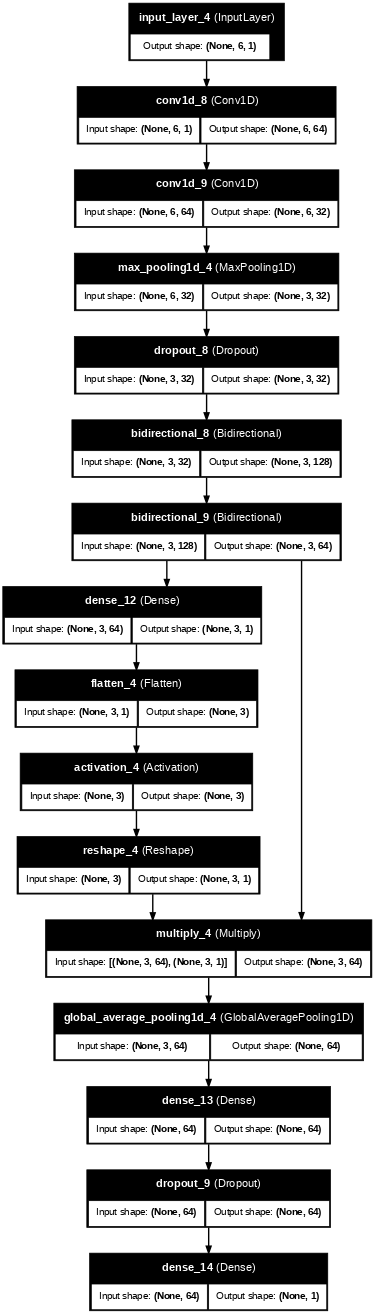


Plot saved: indian_model_architecture.png


In [ ]:
# Save the model plot
tf.keras.utils.plot_model(
    model_indian,
    to_file=SAVE_DIR + 'indian_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=50
)

# Display saved model architecture
display(Image(SAVE_DIR + 'indian_model_architecture.png'))
print("\nPlot saved: indian_model_architecture.png")

# **TRAIN**

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,restore_best_weights=True, verbose=1),
    ModelCheckpoint(SAVE_DIR + 'best_indian_model.h5',monitor='val_auc', save_best_only=True,mode='max', verbose=0)
]

In [ ]:
#5782÷32=180 full batches+1 smaller batch of 22 samples
#= 5782 − 5760 = 22
history = model_indian.fit(
    X_train_3d, y_train,
    validation_data=(X_test_3d, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
178/181 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5907 - auc: 0.4949 - loss: 0.0741 - precision: 0.2762 - recall: 0.2240

181/181 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.5652 - auc: 0.5025 - loss: 0.0746 - precision: 0.3111 - recall: 0.3190 - val_accuracy: 0.3389 - val_auc: 0.5192 - val_loss: 0.0746 - val_precision: 0.3160 - val_recall: 0.9536
Epoch 2/50
180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5627 - auc: 0.5240 - loss: 0.0737 - precision: 0.3144 - recall: 0.3851

181/181 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5187 - auc: 0.5365 - loss: 0.0744 - precision: 0.3376 - recall: 0.5568 - val_accuracy: 0.4765 - val_auc: 0.5399 - val_loss: 0.0744 - val_precision: 0.3277 - val_recall: 0.6380
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5393 - auc: 0.5605 - loss: 0.0738 - precision: 0.3551 - recall: 0.5952

181/181 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5244 - auc: 0.5706 - loss: 0.0739 - precision: 0.3560 - recall: 0.6396 - val_accuracy: 0.6591 - val_auc: 0.5492 - val_loss: 0.0774 - val_precision: 0.3039 - val_recall: 0.0684
Epoch 4/50
180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5649 - auc: 0.5966 - loss: 0.0725 - precision: 0.3738 - recall: 0.5735

181/181 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5441 - auc: 0.5977 - loss: 0.0730 - precision: 0.3716 - recall: 0.6578 - val_accuracy: 0.6342 - val_auc: 0.5849 - val_loss: 0.0750 - val_precision: 0.3914 - val_recall: 0.3024
Epoch 5/50
178/181 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5566 - auc: 0.6020 - loss: 0.0736 - precision: 0.3835 - recall: 0.6219

...

181/181 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7769 - auc: 0.8686 - loss: 0.0495 - precision: 0.6106 - recall: 0.7953 - val_accuracy: 0.8140 - val_auc: 0.9080 - val_loss: 0.0431 - val_precision: 0.6637 - val_recall: 0.8234
Epoch 43/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7783 - auc: 0.8645 - loss: 0.0504 - precision: 0.6138 - recall: 0.7886 - val_accuracy: 0.8084 - val_auc: 0.9047 - val_loss: 0.0446 - val_precision: 0.6600 - val_recall: 0.8013
Epoch 44/50
177/181 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7698 - auc: 0.8647 - loss: 0.0495 - precision: 0.5989 - recall: 0.7741

181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7748 - auc: 0.8692 - loss: 0.0491 - precision: 0.6098 - recall: 0.7815 - val_accuracy: 0.8354 - val_auc: 0.9177 - val_loss: 0.0413 - val_precision: 0.7040 - val_recall: 0.8190
Epoch 45/50
179/181 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7858 - auc: 0.8723 - loss: 0.0494 - precision: 0.6290 - recall: 0.7896

181/181 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7850 - auc: 0.8737 - loss: 0.0489 - precision: 0.6240 - recall: 0.7903 - val_accuracy: 0.8472 - val_auc: 0.9282 - val_loss: 0.0406 - val_precision: 0.7275 - val_recall: 0.8190
Epoch 46/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7859 - auc: 0.8789 - loss: 0.0479 - precision: 0.6219 - recall: 0.8079 - val_accuracy: 0.8416 - val_auc: 0.9243 - val_loss: 0.0400 - val_precision: 0.7137 - val_recall: 0.8256
Epoch 47/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7869 - auc: 0.8783 - loss: 0.0480 - precision: 0.6267 - recall: 0.7914 - val_accuracy: 0.8499 - val_auc: 0.9268 - val_loss: 0.0402 - val_precision: 0.7332 - val_recall: 0.8190
Epoch 48/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7996 - auc: 0.8902 - loss: 0.0464 - precision: 0.6535 - recall: 0.7975

181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.7992 - auc: 0.8903 - loss: 0.0461 - precision: 0.6455 - recall: 0.7969 - val_accuracy: 0.8562 - val_auc: 0.9351 - val_loss: 0.0385 - val_precision: 0.7388 - val_recall: 0.8366
Epoch 49/50
180/181 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8034 - auc: 0.8965 - loss: 0.0445 - precision: 0.6477 - recall: 0.8030

181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7951 - auc: 0.8917 - loss: 0.0456 - precision: 0.6358 - recall: 0.8102 - val_accuracy: 0.8541 - val_auc: 0.9400 - val_loss: 0.0371 - val_precision: 0.7200 - val_recall: 0.8742
Epoch 50/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7930 - auc: 0.8842 - loss: 0.0469 - precision: 0.6324 - recall: 0.8107 - val_accuracy: 0.8119 - val_auc: 0.9243 - val_loss: 0.0406 - val_precision: 0.6434 - val_recall: 0.8962
Restoring model weights from the end of the best epoch: 49.


In [ ]:
model_indian.save(SAVE_DIR + 'indian_model.h5')
print("Model saved: indian_model.h5")

# Save training metrics
indian_metrics = {
    'train_loss':     history.history['loss'][-1],
    'val_loss':       history.history['val_loss'][-1],
    'train_accuracy': history.history['accuracy'][-1],
    'val_accuracy':   history.history['val_accuracy'][-1],
    'train_recall':   history.history['recall'][-1],
    'val_recall':     history.history['val_recall'][-1],
    'train_auc':      history.history['auc'][-1],
    'val_auc':        history.history['val_auc'][-1],
    'epochs_run':     len(history.history['loss'])
}
with open(SAVE_DIR + 'indian_metrics.pkl', 'wb') as f:
    pickle.dump(indian_metrics, f)

print(f"\n  Final Val Accuracy : {indian_metrics['val_accuracy']:.4f}")
print(f"  Final Val Loss     : {indian_metrics['val_loss']:.4f}")
print(f"  Final Val Recall   : {indian_metrics['val_recall']:.4f}")
print(f"  Final Val AUC      : {indian_metrics['val_auc']:.4f}")
print(f"  Epochs ran         : {indian_metrics['epochs_run']} / 50")
print("\nIndian metrics saved")

Model saved: indian_model.h5

  Final Val Accuracy : 0.8119
  Final Val Loss     : 0.0406
  Final Val Recall   : 0.8962
  Final Val AUC      : 0.9243
  Epochs ran         : 50 / 50

Indian metrics saved


# **TRAINING HISTORY PLOTS**

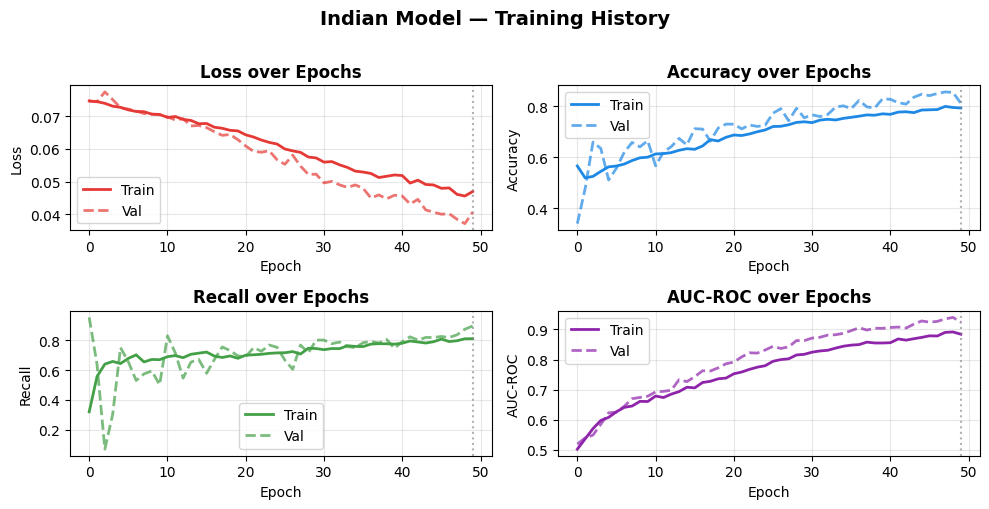


Plot saved: indian_training_history.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
metrics_plot = [
    ('loss',     'val_loss',     'Loss',    '#E53935'),
    ('accuracy', 'val_accuracy', 'Accuracy','#1E88E5'),
    ('recall',   'val_recall',   'Recall',  '#43A047'),
    ('auc',      'val_auc',      'AUC-ROC', '#8E24AA')
]

for ax, (tr_key, va_key, title, color) in zip(axes.flatten(), metrics_plot):
    if tr_key in history.history:
        ax.plot(history.history[tr_key], label='Train',
                color=color, linewidth=2)
        ax.plot(history.history[va_key], label='Val',
                color=color, linewidth=2, linestyle='--', alpha=0.7)
        ax.set_title(f'{title} over Epochs',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(alpha=0.3)
        stopped = len(history.history[tr_key])
        ax.axvline(x=stopped - 1, color='gray',
                   linestyle=':', alpha=0.6,
                   label=f'Stopped @ {stopped}')

plt.suptitle('Indian Model — Training History',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_training_history.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: indian_training_history.png")

# **EVALUATION**

In [ ]:
y_prob = model_indian.predict(X_test_3d).ravel()
y_pred = (y_prob > 0.5).astype(int)
y_pred.shape

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


(1446,)

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred,target_names=['Legit', 'Fraud']))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Classification Report:
              precision    recall  f1-score   support

       Legit       0.94      0.84      0.89       993
       Fraud       0.72      0.87      0.79       453

    accuracy                           0.85      1446
   macro avg       0.83      0.86      0.84      1446
weighted avg       0.87      0.85      0.86      1446


ROC-AUC: 0.9399


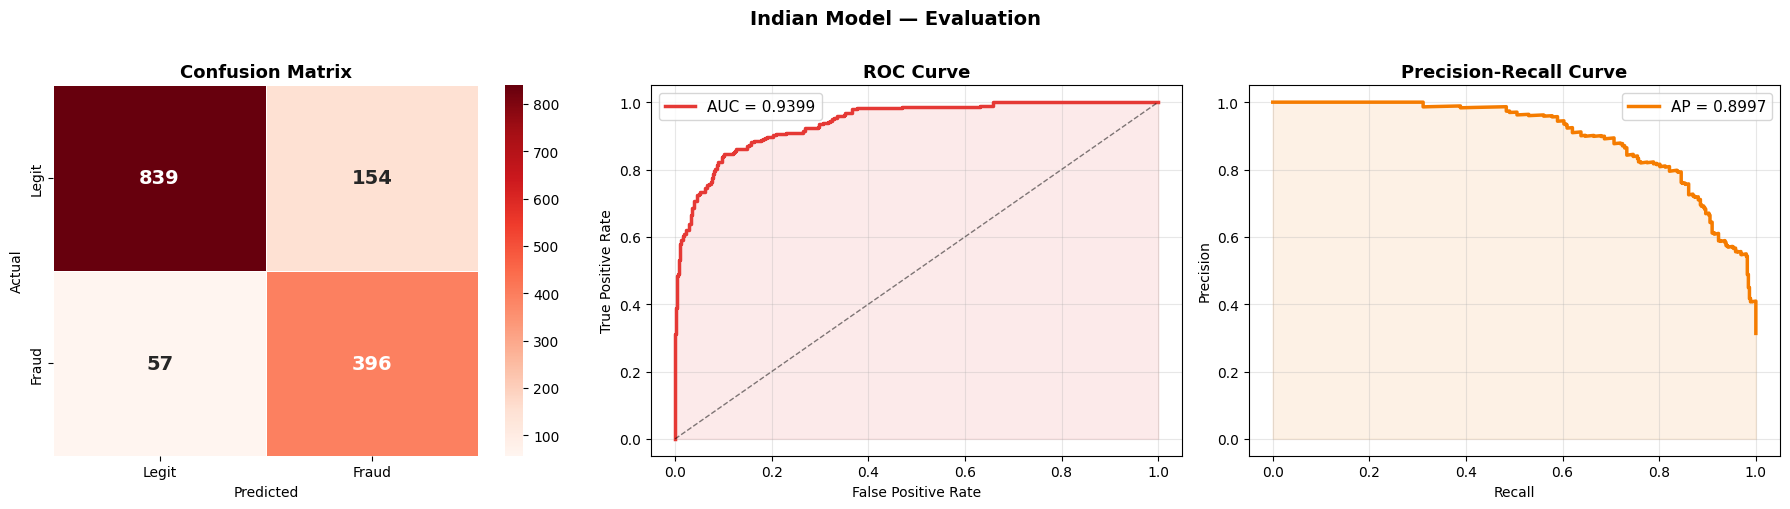


Plot saved: indian_evaluation.png


In [ ]:
# Confusion matrix + ROC + PR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'],
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val      = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#E53935', linewidth=2.5,
             label=f'AUC = {auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E53935')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap            = average_precision_score(y_test, y_prob)
axes[2].plot(rec, prec, color='#F57C00', linewidth=2.5,
             label=f'AP = {ap:.4f}')
axes[2].fill_between(rec, prec, alpha=0.1, color='#F57C00')
axes[2].set_title('Precision-Recall Curve',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(fontsize=11)
axes[2].grid(alpha=0.3)

plt.suptitle('Indian Model — Evaluation',fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_evaluation.png',dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: indian_evaluation.png")

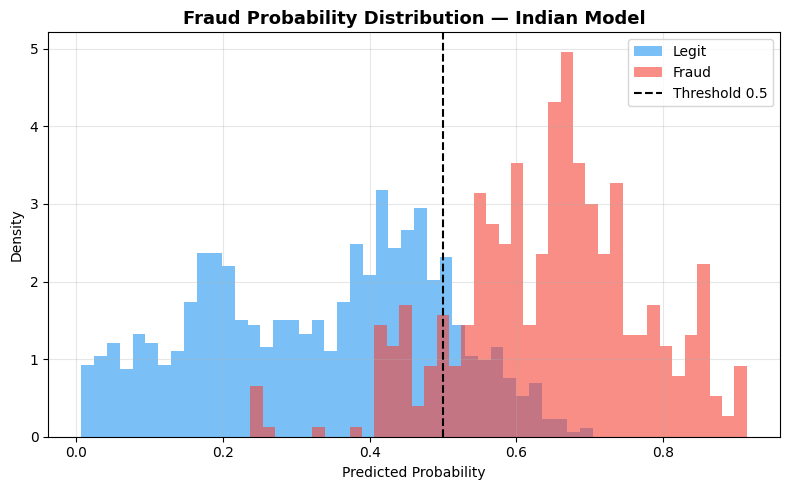


Plot saved: indian_prob_distribution.png


In [ ]:
# Probability Distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_prob[y_test == 0], bins=40, color='#2196F3',
        alpha=0.6, label='Legit', density=True)
ax.hist(y_prob[y_test == 1], bins=40, color='#F44336',
        alpha=0.6, label='Fraud', density=True)
ax.axvline(0.5, color='black', linestyle='--',
           linewidth=1.5, label='Threshold 0.5')
ax.set_title('Fraud Probability Distribution — Indian Model',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_prob_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: indian_prob_distribution.png")

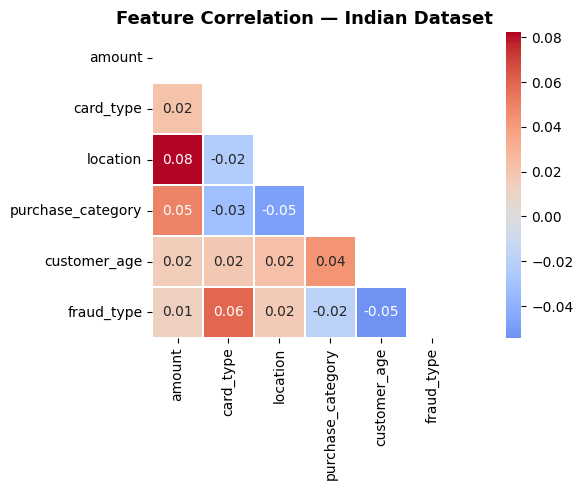


Plot saved: indian_correlation.png


In [ ]:
# Feature Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 5))
corr = pd.DataFrame(X_test, columns=feature_names).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.3, square=True)
ax.set_title('Feature Correlation — Indian Dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: indian_correlation.png")

# **SHAP EXPLAINABILITY**

In [ ]:
background   = X_train_3d[:50]
explain_data = X_test_3d[:30]

print(f"  Background shape : {background.shape}")
print(f"  Explain shape    : {explain_data.shape}")
print("  Computing SHAP values...")

explainer       = shap.GradientExplainer(model_indian, background)
shap_values     = explainer.shap_values(explain_data)

sv_2d = np.array(shap_values).squeeze()
if sv_2d.ndim == 3:
    sv_2d = sv_2d.mean(axis=1)

X_sample_2d = explain_data.squeeze()   # (30, n_features)

# GradientExplainer has no expected_value — use mean prediction as base_val
base_val = float(model_indian.predict(background).mean())

print(f"  SHAP values shape : {sv_2d.shape}")
print(f"  Base value        : {base_val:.4f}")

  Background shape : (50, 6, 1)
  Explain shape    : (30, 6, 1)
  Computing SHAP values...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
  SHAP values shape : (30, 6)
  Base value        : 0.3921


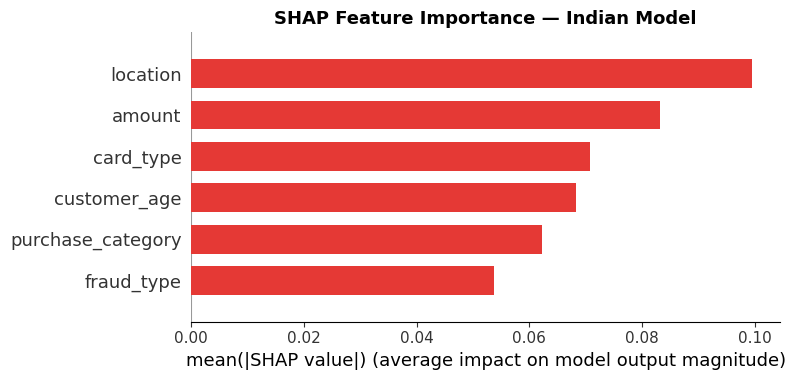


Plot saved: indian_shap_bar.png


In [ ]:
# ── SHAP Plot 1: Bar (Feature Importance) ────────────────────
plt.figure(figsize=(9, 5))
shap.summary_plot(sv_2d, explain_data.squeeze(),
                  feature_names=feature_names,
                  plot_type='bar', show=False,
                  color='#E53935')
plt.title('SHAP Feature Importance — Indian Model',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_shap_bar.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: indian_shap_bar.png")

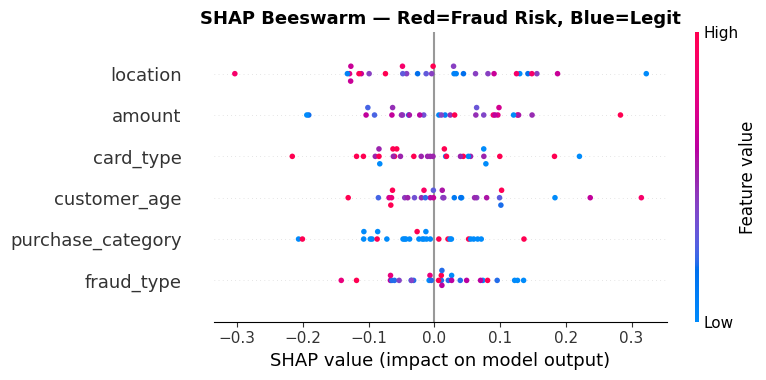


Plot saved: indian_shap_beeswarm.png


In [ ]:
# ── SHAP Plot 2: Beeswarm ─────────────────────────────────────
plt.figure(figsize=(9, 4 ))
shap.summary_plot(sv_2d, explain_data.squeeze(),
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Beeswarm — Red=Fraud Risk, Blue=Legit',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: indian_shap_beeswarm.png")

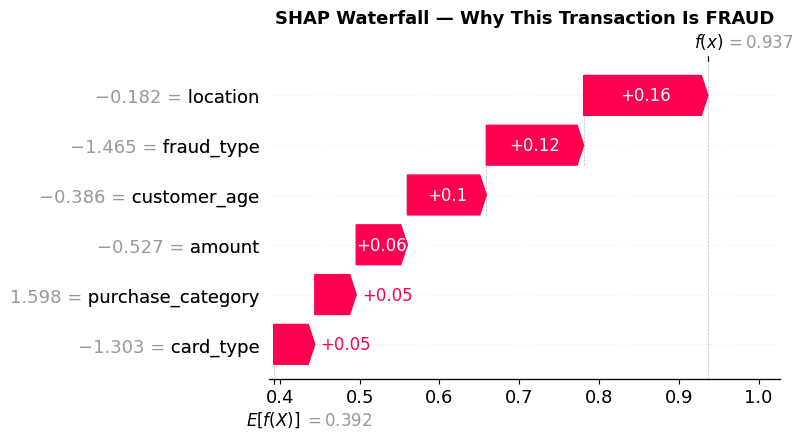


Plot saved: indian_shap_waterfall.png


In [ ]:
# ── SHAP Plot 3: Waterfall (Single Fraud Prediction) ─────────
# Step-by-step: base value → final prediction for one fraud sample
fraud_indices = np.where(y_test[:30] == 1)[0]
wf_idx        = fraud_indices[0] if len(fraud_indices) > 0 else 0

shap_exp_wf = shap.Explanation(
    values       = sv_2d[wf_idx],
    base_values  = base_val,
    data         = X_sample_2d[wf_idx],
    feature_names= feature_names
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_exp_wf, max_display=15, show=False)
plt.title('SHAP Waterfall — Why This Transaction Is FRAUD',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: indian_shap_waterfall.png")


In [ ]:
# Print top 3 fraud reasons
print("\n  Top 3 reasons this transaction is FRAUD:")
top3 = np.argsort(np.abs(sv_2d[wf_idx]))[::-1][:3]
for rank, j in enumerate(top3, 1):
    direction = "increases fraud risk" if sv_2d[wf_idx][j] > 0 \
                else "decreases fraud risk"
    print(f"  {rank}. {feature_names[j]:20s} = "
          f"{X_sample_2d[wf_idx][j]:.3f} "
          f"→ {direction} "
          f"(SHAP: {sv_2d[wf_idx][j]:+.4f})")


  Top 3 reasons this transaction is FRAUD:
  1. location             = -0.182 → increases fraud risk (SHAP: +0.1558)
  2. fraud_type           = -1.465 → increases fraud risk (SHAP: +0.1220)
  3. customer_age         = -0.386 → increases fraud risk (SHAP: +0.0990)


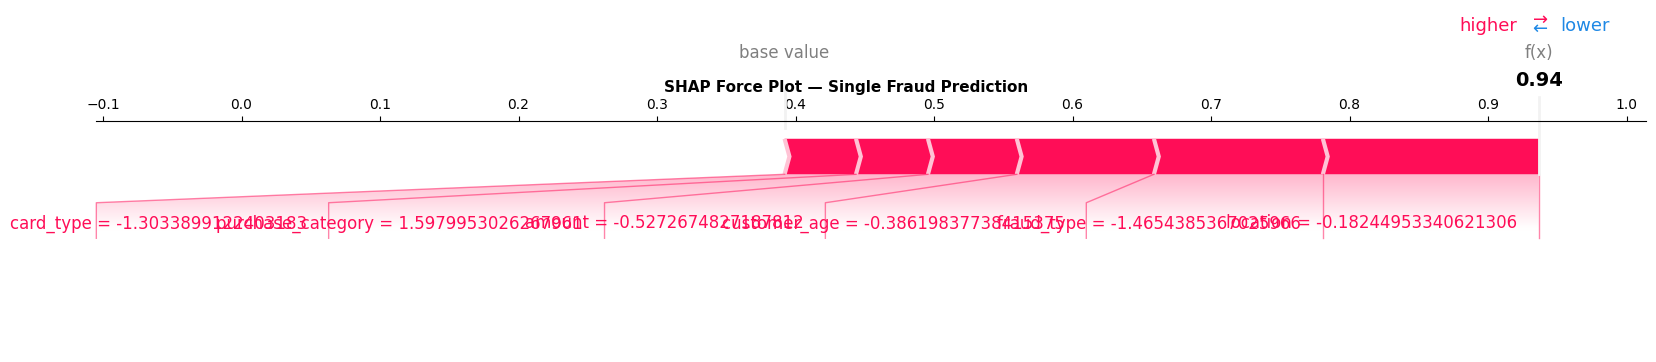


 Plot saved: indian_shap_force.png


In [ ]:
# ── SHAP Plot 4: Force Plot (Single Prediction) ───────────────
# Push/pull visualization — Red = increases fraud risk, Blue = decreases
shap.force_plot(
    base_val,
    sv_2d[wf_idx],
    X_sample_2d[wf_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.gcf().suptitle('SHAP Force Plot — Single Fraud Prediction',fontsize=11, fontweight='bold', y=1.02)
plt.savefig(SAVE_DIR + 'indian_shap_force.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Plot saved: indian_shap_force.png")

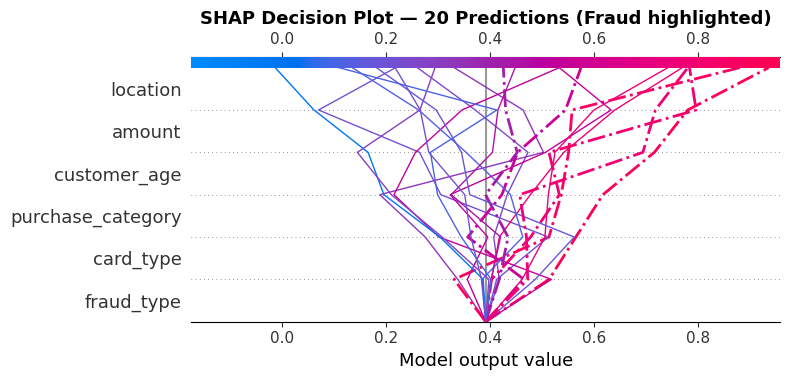


 Plot saved: indian_shap_decision.png


In [ ]:
# ── SHAP Plot 5: Decision Plot (Multiple Predictions) ────────
# Line paths from base value → final prediction for multiple samples
# Highlight fraud samples vs legit samples
n_decision   = min(20, len(sv_2d))
highlight_idx = [i for i in range(n_decision) if y_test[i] == 1]

plt.figure(figsize=(10, 8))
shap.decision_plot(
    base_val,
    sv_2d[:n_decision],
    X_sample_2d[:n_decision],
    feature_names=feature_names,
    highlight=highlight_idx,
    show=False
)
plt.title(f'SHAP Decision Plot — {n_decision} Predictions '
          f'(Fraud highlighted)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_shap_decision.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Plot saved: indian_shap_decision.png")

<Figure size 900x600 with 0 Axes>

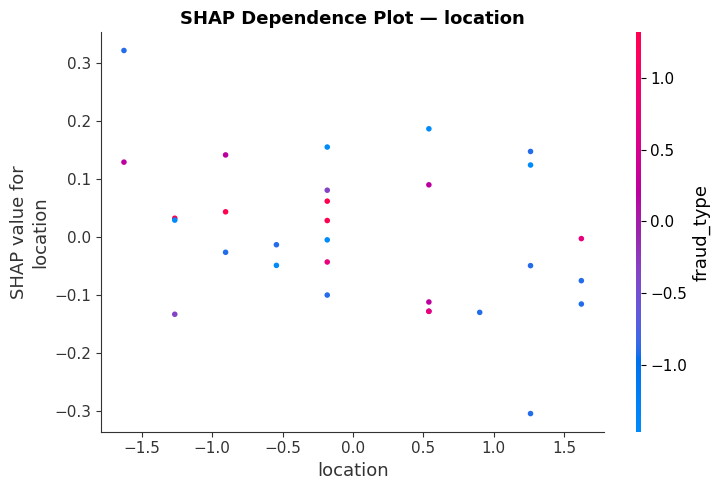


Plot saved: indian_shap_dependence.png  (feature: location)


In [ ]:
# ── SHAP Plot 6: Dependence Plot (Top Feature) ────────────────
# Scatter: feature value vs SHAP value, colored by interaction feature
top_feat_idx  = int(np.argmax(np.abs(sv_2d).mean(axis=0)))
top_feat_name = feature_names[top_feat_idx]

plt.figure(figsize=(9, 6))
shap.dependence_plot(
    top_feat_idx,
    sv_2d,
    X_sample_2d,
    feature_names=feature_names,
    show=False
)
plt.title(f'SHAP Dependence Plot — {top_feat_name}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved: indian_shap_dependence.png  (feature: {top_feat_name})")

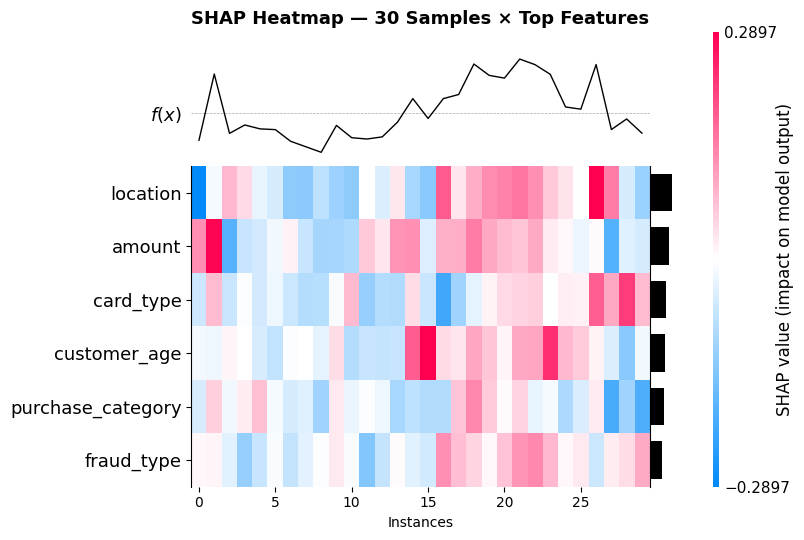


Plot saved: indian_shap_heatmap.png


In [ ]:
# ── SHAP Plot 7: Heatmap ──────────────────────────────────────
# Matrix of SHAP values — rows=samples, cols=features; spot patterns
shap_exp_all = shap.Explanation(
    values       = sv_2d,
    base_values  = np.full(len(sv_2d), base_val),
    data         = X_sample_2d,
    feature_names= feature_names
)
plt.figure(figsize=(14, 7))
shap.plots.heatmap(shap_exp_all, max_display=15, show=False)
plt.title('SHAP Heatmap — 30 Samples × Top Features',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_shap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: indian_shap_heatmap.png")

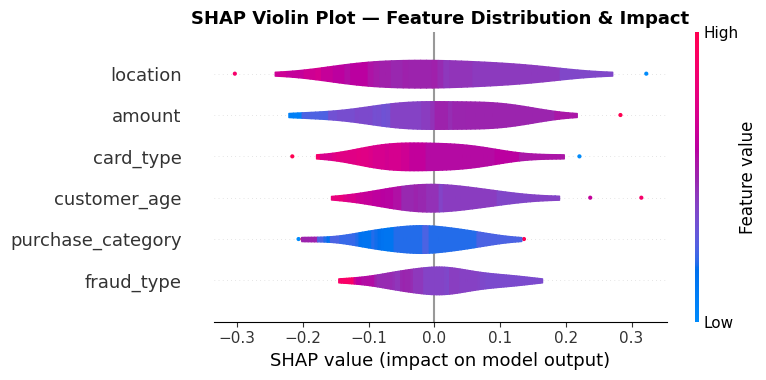


 Plot saved: indian_shap_violin.png


In [ ]:
# ── SHAP Plot 8: Violin Plot ──────────────────────────────────
# Feature distribution + SHAP values — density & spread combined
plt.figure(figsize=(9, 6))
shap.summary_plot(sv_2d, X_sample_2d,
                  feature_names=feature_names,
                  plot_type='violin',
                  show=False,
                  max_display=15)
plt.title('SHAP Violin Plot — Feature Distribution & Impact',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'indian_shap_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n Plot saved: indian_shap_violin.png")

In [ ]:
# ── Save SHAP data ────────────────────────────────────────────
with open(SAVE_DIR + 'shap_explainer_indian.pkl', 'wb') as f:
    pickle.dump({
        'shap_values':   sv_2d,
        'feature_names': feature_names,
        'X_sample':      explain_data.squeeze(),
        'base_value': base_val
    }, f)
print("\nSHAP data saved: shap_explainer_indian.pkl")


SHAP data saved: shap_explainer_indian.pkl


In [ ]:
# ── Save test data ────────────────────────────────────────────
np.save(SAVE_DIR + 'indian_X_test.npy', X_test)
np.save(SAVE_DIR + 'indian_y_test.npy', y_test)
print("Test data saved")

Test data saved


# **FINAL SUMMARY**

In [ ]:
print("INDIAN TRAINING COMPLETE ")
print("="*60)
print(f"  Val Accuracy : {indian_metrics['val_accuracy']:.4f}")
print(f"  Val Loss     : {indian_metrics['val_loss']:.4f}")
print(f"  Val Recall   : {indian_metrics['val_recall']:.4f}")
print(f"  Val AUC      : {indian_metrics['val_auc']:.4f}")
print(f"  Epochs ran   : {indian_metrics['epochs_run']} / 50")
print("="*60)
print("\nFiles saved:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(SAVE_DIR + f)
    print(f"  {f:<45} {size/1024:.1f} KB")


INDIAN TRAINING COMPLETE 
  Val Accuracy : 0.8119
  Val Loss     : 0.0406
  Val Recall   : 0.8962
  Val AUC      : 0.9243
  Epochs ran   : 50 / 50

Files saved:
  best_euro_model.h5                            1282.9 KB
  best_indian_model.h5                          1282.9 KB
  euro_X_test.npy                               12905.6 KB
  euro_amount_distribution.png                  56.9 KB
  euro_class_distribution.png                   50.3 KB
  euro_evaluation.png                           109.4 KB
  euro_metrics.pkl                              0.2 KB
  euro_model.h5                                 1282.9 KB
  euro_model_architecture.png                   76.0 KB
  euro_prob_distribution.png                    35.8 KB
  euro_shap_bar.png                             57.5 KB
  euro_shap_beeswarm.png                        106.7 KB
  euro_shap_decision.png                        272.6 KB
  euro_shap_dependence.png                      43.5 KB
  euro_shap_force.png                       